# **Movie Analyzer Dashboard**
This notebook contains the data preparation and analysis workflow for the Movie Analyzer Dashboard. Movie data is collected through the TMDB API and processed using Python and Pandas.

The workflow covers data collection, cleaning, preprocessing, exploratory data analysis, and analytical preparation for Power BI. The analysis focuses on movie trends, genres, languages, ratings, budgets, revenue, and other key attributes.

In [ ]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

In [ ]:
from dotenv import load_dotenv

load_dotenv("../.env")

True

In [ ]:
api_key = os.getenv("TMDB_API_KEY")

print("API key loaded:", api_key is not None)

API key loaded: True


def fetch_page(page):

    url = "https://api.themoviedb.org/3/discover/movie"

    params = {
        "api_key" = os.getenv("TMDB_API_KEY"),
        "language": "en-US",
        "page": page
    }

    # Try maximum 3 times
    for attempt in range(3):

        try:
            response = requests.get(
                url,
                params=params,
                timeout=10
            )

            # Raise error if status code is 4xx or 5xx
            response.raise_for_status()

            # Convert API data into DataFrame
            temp_df = pd.DataFrame(
                response.json()["results"]
            )

            print(f"Page {page}: Fetched successfully")

            return temp_df

        except requests.exceptions.RequestException:

            print(
                f"Page {page}: Unable to fetch | "
                f"Attempt {attempt + 1}/3"
            )

            # Wait before retrying
            if attempt < 2:

                wait_time = [1, 1.5, 2][attempt]

                print(f"Waiting {wait_time} seconds...")
                time.sleep(wait_time)

    # This runs only if all attempts fail
    print(f"Page {page}: Permanently failed")

    return None *italicised text*

df_list = []
failed_pages = []


for page in range(1, 501):

    temp_df = fetch_page(page)

    if temp_df is not None:

        df_list.append(temp_df)

    else:

        failed_pages.append(page)

df = pd.concat(df_list, ignore_index=True)

print("\nFinal DataFrame Shape:")
print(df.shape)

print("\nFailed Pages:")
print(failed_pages)

In [ ]:
df = pd.read_csv('/content/tmdb_movies.csv')

In [ ]:
df['id'].duplicated().sum()

np.int64(1582)

In [ ]:
# Remove duplicate movies based on TMDB movie ID
df = df.drop_duplicates(
    subset="id",
    keep="first"
).reset_index(drop=True)

In [ ]:
genre_id = requests.get(f"https://api.themoviedb.org/3/genre/movie/list?api_key={api_key}&language=en-US")
genre_id.raise_for_status()
genre_id

<Response [200]>

In [ ]:
genre_id.json()

{'genres': [{'id': 28, 'name': 'Action'},
  {'id': 12, 'name': 'Adventure'},
  {'id': 16, 'name': 'Animation'},
  {'id': 35, 'name': 'Comedy'},
  {'id': 80, 'name': 'Crime'},
  {'id': 99, 'name': 'Documentary'},
  {'id': 18, 'name': 'Drama'},
  {'id': 10751, 'name': 'Family'},
  {'id': 14, 'name': 'Fantasy'},
  {'id': 36, 'name': 'History'},
  {'id': 27, 'name': 'Horror'},
  {'id': 10402, 'name': 'Music'},
  {'id': 9648, 'name': 'Mystery'},
  {'id': 10749, 'name': 'Romance'},
  {'id': 878, 'name': 'Science Fiction'},
  {'id': 10770, 'name': 'TV Movie'},
  {'id': 53, 'name': 'Thriller'},
  {'id': 10752, 'name': 'War'},
  {'id': 37, 'name': 'Western'}]}

In [ ]:
dic = {}
for i in genre_id.json()['genres']:
  dic[i['id']] = i['name']

print(dic)

{28: 'Action', 12: 'Adventure', 16: 'Animation', 35: 'Comedy', 80: 'Crime', 99: 'Documentary', 18: 'Drama', 10751: 'Family', 14: 'Fantasy', 36: 'History', 27: 'Horror', 10402: 'Music', 9648: 'Mystery', 10749: 'Romance', 878: 'Science Fiction', 10770: 'TV Movie', 53: 'Thriller', 10752: 'War', 37: 'Western'}


In [ ]:
df['genre_ids'][0]

'[878, 28, 12]'

In [ ]:
list_genre_ids = []
for i in range (len(df['genre_ids'])):
  temp = []
  #print(df['genre_ids'][i][1:-1].split(", "))
  for j in df['genre_ids'][i][1:-1].split(", "):
    temp.append(int(j) if j != '' else j)
  list_genre_ids.append(temp)

print(list_genre_ids)

[[878, 28, 12], [12, 28, 14], [28, 53], [35, 12, 10751], [10749], [80, 28, 53], [10749, 18], [53], [28, 80, 18], [80, 18, 53], [27, 53], [27, 14, 9648], [28, 27, 878], [28, 878, 53], [27, 35, 53], [16, 10751, 35, 12], [12, 16, 35, 10751, 14], [10751, 14, 35, 12], [28, 53, 27, 80], [16, 28, 12, 878, 80, 18], [35, 18, 53], [28, 12, 878], [18, 80], [27, 9648, 878], [878, 53], [878, 12], [12, 18, 28], [878, 12, 53], [14, 12, 27], [35], [27, 53], [28, 12, 878], [16, 28, 12, 14], [18, 10749], [878, 53], [12, 28, 878], [35, 53], [878, 28, 12], [27, 53], [18, 53, 9648], [28, 14, 878], [878, 12, 14], [35, 18], [28, 53, 80], [12, 14, 28], [16, 28, 14], [28, 10752], [35], [28, 12, 878], [27, 878, 53], [53, 80], [53], [878, 9648, 53], [16, 12, 35, 9648, 10751], [16, 28, 12, 878], [27], [10402, 18], [27, 53], [27], [35], [10751, 35, 12, 14, 16], [18, 80], [27], [28, 878], [10749], [12, 878, 28], [28, 80, 53], [18, 80], [28, 80, 18, 53], [53], [28, 18, 80], [80, 18], [18, 10770], [18], [28, 12, 878]

In [ ]:
df['genre_ids'] = list_genre_ids

In [ ]:
print(df['genre_ids'][0], type(df['genre_ids'][0]))

[878, 28, 12] <class 'list'>


In [ ]:
print(type(list_genre_ids))
print(type(list_genre_ids[0][0]))

<class 'list'>
<class 'int'>


In [ ]:
df.shape

(8418, 15)

In [ ]:
df.columns.tolist()

['adult',
 'backdrop_path',
 'genre_ids',
 'id',
 'title',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'poster_path',
 'release_date',
 'softcore',
 'video',
 'vote_average',
 'vote_count']

In [ ]:
df.head(2)

,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count
0,False,/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg,"[878, 28, 12]",969681,Spider-Man: Brand New Day,en,Spider-Man: Brand New Day,Fighting crime full-time as Spider-Man in a wo...,857.7444,/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg,2026-07-29,False,False,7.878,2402
1,False,/twiVn9oFXOVR0uoYgawyEBlnFu8.jpg,"[12, 28, 14]",1368337,The Odyssey,en,The Odyssey,"Odysseus, the legendary King of Ithaca, embark...",497.9764,/5rhTDKUhPYvpdQIijFIs5VoWsON.jpg,2026-07-15,False,False,7.997,3440


In [ ]:
genre_list = []

for i in df['genre_ids']:
  temp = []
  #print(i)
  for j in i:
    #print(j)
    temp.append(dic[j] if j != '' else 'Unknown')
  genre_list.append(temp)

genre_list

[['Science Fiction', 'Action', 'Adventure'],
 ['Adventure', 'Action', 'Fantasy'],
 ['Action', 'Thriller'],
 ['Comedy', 'Adventure', 'Family'],
 ['Romance'],
 ['Crime', 'Action', 'Thriller'],
 ['Romance', 'Drama'],
 ['Thriller'],
 ['Action', 'Crime', 'Drama'],
 ['Crime', 'Drama', 'Thriller'],
 ['Horror', 'Thriller'],
 ['Horror', 'Fantasy', 'Mystery'],
 ['Action', 'Horror', 'Science Fiction'],
 ['Action', 'Science Fiction', 'Thriller'],
 ['Horror', 'Comedy', 'Thriller'],
 ['Animation', 'Family', 'Comedy', 'Adventure'],
 ['Adventure', 'Animation', 'Comedy', 'Family', 'Fantasy'],
 ['Family', 'Fantasy', 'Comedy', 'Adventure'],
 ['Action', 'Thriller', 'Horror', 'Crime'],
 ['Animation', 'Action', 'Adventure', 'Science Fiction', 'Crime', 'Drama'],
 ['Comedy', 'Drama', 'Thriller'],
 ['Action', 'Adventure', 'Science Fiction'],
 ['Drama', 'Crime'],
 ['Horror', 'Mystery', 'Science Fiction'],
 ['Science Fiction', 'Thriller'],
 ['Science Fiction', 'Adventure'],
 ['Adventure', 'Drama', 'Action'],
 ['

In [ ]:
len(genre_list)

8418

In [ ]:
df['genre'] = genre_list

In [ ]:
df.head(2)

,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count,genre
0,False,/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg,"[878, 28, 12]",969681,Spider-Man: Brand New Day,en,Spider-Man: Brand New Day,Fighting crime full-time as Spider-Man in a wo...,857.7444,/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg,2026-07-29,False,False,7.878,2402,"[Science Fiction, Action, Adventure]"
1,False,/twiVn9oFXOVR0uoYgawyEBlnFu8.jpg,"[12, 28, 14]",1368337,The Odyssey,en,The Odyssey,"Odysseus, the legendary King of Ithaca, embark...",497.9764,/5rhTDKUhPYvpdQIijFIs5VoWsON.jpg,2026-07-15,False,False,7.997,3440,"[Adventure, Action, Fantasy]"


from concurrent.futures import ThreadPoolExecutor, as_completed


# ---------------------------------------------------------
# 1. API configuration
# ---------------------------------------------------------

api_key = "01388f281ae3c5a1db7b053ec80de46b"
language = "en-US"


# ---------------------------------------------------------
# 2. Function to fetch details for ONE movie
# ---------------------------------------------------------

def fetch_movie_detail(movie_id):

    url = f"https://api.themoviedb.org/3/movie/{movie_id}"

    params = {
        "api_key": api_key,
        "language": language
    }

    # Try up to 3 times
    for attempt in range(3):

        try:

            response = requests.get(
                url,
                params=params,
                timeout=10
            )

            # Successful request
            if response.status_code == 200:
                return movie_id, response.json()

            # Rate limit
            elif response.status_code == 429:

                print(f"Movie {movie_id}: Rate limited (429)")

                # Wait before trying again
                time.sleep(2)

            # Movie not found
            elif response.status_code == 404:

                print(f"Movie {movie_id}: Movie not found")
                return movie_id, None

            # Other HTTP errors
            else:

                print(
                    f"Movie {movie_id}: "
                    f"HTTP {response.status_code} | "
                    f"Attempt {attempt + 1}/3"
                )

                time.sleep(1)

        except requests.exceptions.RequestException as e:

            print(
                f"Movie {movie_id}: "
                f"Request error | "
                f"Attempt {attempt + 1}/3 | {e}"
            )

            time.sleep(1)

    # All attempts failed
    print(f"Movie {movie_id}: Permanently failed")

    return movie_id, None

# ---------------------------------------------------------
# 3. Get movie IDs from your main DataFrame
# ---------------------------------------------------------

movie_ids = df["id"].tolist()


# ---------------------------------------------------------
# 4. Fetch movie details concurrently
# ---------------------------------------------------------

movie_details = []
failed_movie_ids = []


# Create 15 concurrent workers
with ThreadPoolExecutor(max_workers=15) as executor:

    # Submit one task for every movie ID
    futures = [
        executor.submit(fetch_movie_detail, movie_id)
        for movie_id in movie_ids
    ]

    # Process each request as soon as it finishes
    for future in as_completed(futures):

        # fetch_movie_detail() returns:
        # (movie_id, result)
        movie_id, result = future.result()

        # If API request was successful
        if result is not None:

            # Explicitly store the movie ID in the response.
            # This guarantees that we know which movie
            # this API response belongs to.
            result["id"] = movie_id

            # Store the complete movie-detail dictionary
            movie_details.append(result)

        # If API request failed
        else:

            # Keep track of the failed movie ID
            failed_movie_ids.append(movie_id)


# ---------------------------------------------------------
# 5. Convert successful API responses into DataFrame
# ---------------------------------------------------------

data_df = pd.DataFrame(movie_details)


# ---------------------------------------------------------
# 6. Check for duplicate movie IDs in the API results
# ---------------------------------------------------------

duplicate_count = data_df["id"].duplicated().sum()

print("Duplicate IDs in data_df:", duplicate_count)


# ---------------------------------------------------------
# 7. Remove duplicate API responses, if any
# ---------------------------------------------------------

data_df = data_df.drop_duplicates(
    subset="id",
    keep="first"
)


# ---------------------------------------------------------
# 8. Display fetching results
# ---------------------------------------------------------

print("\nTotal movies requested:", len(movie_ids))
print("Successfully fetched:", len(data_df))
print("Failed movies:", len(failed_movie_ids))

print("\nFailed Movie IDs:")
print(failed_movie_ids)

data_df.to_csv('data_df.csv')

In [ ]:
data_df = pd.read_csv('/content/data_df.csv')

In [ ]:
data_df

,Unnamed: 0,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,...,revenue,runtime,softcore,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,0,False,/zFCWfU2ViMIm38G1W8UsnSpqmWn.jpg,NaN,0,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ...",https://www.amazon.com/dp/B0H8Q1DKGJ,1516698,tt37654096,['US'],...,0,107,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,One summer to feel everything.,The Last Sunrise,False,6.678,108
1,1,False,/dNKFETDDujxm2PUN873Jwiw5VML.jpg,NaN,500000,"[{'id': 27, 'name': 'Horror'}, {'id': 14, 'nam...",https://www.altitude.film/pinocchio-unstrung,1232569,tt30887701,['GB'],...,815692,82,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,He has no strings to hold him back now.,Pinocchio: Unstrung,False,6.700,79
2,2,False,/c4U96GrPRfnNrS01mBtqnocvlLJ.jpg,NaN,0,"[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name...",https://www.netflix.com/title/82048151,1621552,tt39390497,['MX'],...,0,91,False,"[{'english_name': 'Portuguese', 'iso_639_1': '...",Released,NaN,Facing El Chapo,False,8.837,492
3,3,False,/qDa0fqDqIBCovRp975RvtGPcuN3.jpg,NaN,40000000,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",https://www.mutiny.movie,1288445,tt32338669,['US'],...,20824283,95,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,There's blood in the water.,Mutiny,False,6.371,264
4,4,False,/tK3QdOOrX4qEkmSlvrmc8cK7iOU.jpg,"{'id': 1679602, 'name': 'Ghost in the Cell Col...",0,"[{'id': 27, 'name': 'Horror'}, {'id': 35, 'nam...",NaN,1393326,tt9000310,['ID'],...,0,106,False,"[{'english_name': 'Indonesian', 'iso_639_1': '...",Released,NaN,Ghost in the Cell,False,7.024,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8413,8413,False,/f2z00VIPyrrfFabw0RnoY5M8uYt.jpg,NaN,50000000,"[{'id': 18, 'name': 'Drama'}, {'id': 14, 'name...",http://hereafter.warnerbros.com/,44603,tt1212419,['US'],...,107000000,129,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Touched by death. Changed by life.,Hereafter,False,6.147,1851
8414,8414,False,/hZARFbBT4I3svc6TAnaHrhTyKbc.jpg,NaN,35000000,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",https://www.miramax.com/movie/bounce,10862,tt0186894,['US'],...,36779296,107,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Two strangers fell in love. One knew it wasn't...,Bounce,False,5.812,421
8415,8415,False,/vsSZGWz0HgGrSjmr0t9wjXNSnAA.jpg,NaN,0,"[{'id': 27, 'name': 'Horror'}, {'id': 53, 'nam...",http://karadedelerolayi.net,85579,tt2036391,['TR'],...,0,86,False,"[{'english_name': 'Turkish', 'iso_639_1': 'tr'...",Released,Get ready to be shocked!,The Karadedeler Incident,False,2.464,14
8416,8416,False,/mVHPPi946Qu1gEIthe5SCt9QHT5.jpg,NaN,0,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ...",http://localfilms.celeonet.fr/wp/2020/12/la-nu...,784130,tt13779412,['FR'],...,0,88,False,"[{'english_name': 'French', 'iso_639_1': 'fr',...",Released,NaN,The Night Belongs to Lovers,False,5.700,20


In [ ]:
# ============================================================
# PRODUCTION COMPANIES
# ============================================================


# ------------------------------------------------------------
# 1. Convert production_companies strings into dictionaries
# ------------------------------------------------------------

list_df = list(list(data_df['production_companies']))

## production_companies

data_str = list_df
big_L = []

for item in data_str:
  L = []
  item_stripped = item.strip("[]")
  item_split = item_stripped.split("}, ")
  #print(item_split)
  for i in item_split:
    temp_dict = {}
    last_key = None
    parts = i.split(", ")
    print(parts)
    for j in parts:
      split_j = j.split(": ", 1)

      print(split_j, last_key)
      if len(split_j) < 2:
        if last_key is not None:
          temp_dict[last_key] += ', ' + j.strip("[]\"'{} ")
        continue
      key = split_j[0].strip("\"'{} ")
      value = split_j[1].strip("\"'{} ")
      temp_dict[key] = value
      last_key = key
    L.append(temp_dict)
  big_L.append(L)

# ------------------------------------------------------------
# 2. Create temporary dataframe
# ------------------------------------------------------------

data_df['production_companies'] = big_L

# ------------------------------------------------------------
# 3. Create production companies map using movie ID
# ------------------------------------------------------------

production_countries_map = {}

for i in range(len(data_df)):

    movie_id = data_df['id'][i]
    companies = data_df['production_companies'][i]

    # print(movie_id)
    # print(companies)

    production_countries_map[movie_id] = companies

    production_countries_map


# ------------------------------------------------------------
# 4. Map production companies to df_temp
# ------------------------------------------------------------

df['production_companies'] = df['id'].map(
    production_countries_map
)

df[['id', 'production_companies']].head(1).iloc[0, 1]


# ------------------------------------------------------------
# 5. Keep only company names
# ------------------------------------------------------------

production_companies_list = []

for i in df['production_companies']:

    temp_list = []

    print(i)

    if not isinstance(i, list):
        production_companies_list.append(['Unknown'])
        continue

    for j in i:

        if isinstance(j, dict) and 'name' in j:
            temp_list.append(j['name'])

    if len(temp_list) == 0:
        temp_list.append('Unknown')

    production_companies_list.append(temp_list)


df['production_companies'] = production_companies_list

Streaming output truncated to the last 5000 lines.
[{'id': '5', 'logo_path': '/71BqEFAF4V3qjjMPCpLuyJFB9A.png', 'name': 'Columbia Pictures', 'origin_country': 'US'}, {'id': '333', 'logo_path': '/5xUJfzPZ8jWJUDzYtIeuPO4qPIa.png', 'name': 'Original Film', 'origin_country': 'US'}]
[{'id': '17829', 'logo_path': '/7lZU96hRoJeJYwp8r6m3Vwa90Nk.png', 'name': 'Kino Films', 'origin_country': 'JP'}, {'id': '73025', 'logo_path': '/zYb2OfWjKvNlngpq4LemY9JVC51.png', 'name': 'Kinoshita Group', 'origin_country': 'JP'}]
[{'id': '148496', 'logo_path': '/737HCq9hXnI801p8sSAMJIvCidg.png', 'name': 'WildBrain Studios', 'origin_country': 'CA'}, {'id': '16339', 'logo_path': '/wx2xFdBxcrDFoB2ethHQ8LjiknX.png', 'name': 'Charles M. Schulz Creative Associates', 'origin_country': 'US'}]
[{'id': '296589', 'logo_path': 'None', 'name': 'Stamptown', 'origin_country': ''}, {'id': '64264', 'logo_path': '/AgKhE4VyVeFLRWVlerhDUWGKeKH.png', 'name': 'Abso Lutely Productions', 'origin_country': 'US'}]
[{'id': '21', 'logo_pat

In [ ]:
# ============================================================
# PRODUCTION COUNTRIES
# ============================================================


# ------------------------------------------------------------
# 1. Convert production_countries strings into dictionaries
# ------------------------------------------------------------

list_production_countries = list(
    list(data_df['production_countries'])
)

data_str = list_production_countries
big_production_countries = []

for item in data_str:
    L = []

    item_stripped = item.strip("[]")
    item_split = item_stripped.split("}, ")

    # print(item_split)

    for i in item_split:
        temp_dict = {}
        last_key = None

        parts = i.split(", ")
        print(parts)

        for j in parts:
            split_j = j.split(": ", 1)

            print(split_j, last_key)

            if len(split_j) < 2:
                if last_key is not None:
                    temp_dict[last_key] += ', ' + j.strip("[]\"'{} ")
                continue

            key = split_j[0].strip("\"'{} ")
            value = split_j[1].strip("\"'{} ")

            temp_dict[key] = value
            last_key = key

        L.append(temp_dict)

    big_production_countries.append(L)


# ------------------------------------------------------------
# 2. Create production countries map using movie ID
# ------------------------------------------------------------

production_countries_map = {}

for i in range(len(data_df)):

    movie_id = data_df['id'].iloc[i]
    countries = big_production_countries[i]

    production_countries_map[movie_id] = countries


# ------------------------------------------------------------
# 3. Map production countries to df_temp
# ------------------------------------------------------------

df['production_countries'] = df['id'].map(
    production_countries_map
)


# ------------------------------------------------------------
# 4. Keep only country names
# ------------------------------------------------------------

production_countries_list = []

for i in df['production_countries']:

    temp_list = []

    print(i)

    if not isinstance(i, list):

        temp_list.append('Unknown')

    else:

        for j in i:

            if isinstance(j, dict) and 'name' in j:
                temp_list.append(j['name'])

            else:
                temp_list.append('Unknown')

    production_countries_list.append(temp_list)


df['production_countries'] = production_countries_list

Streaming output truncated to the last 5000 lines.
[{'iso_3166_1': 'GB', 'name': 'United Kingdom'}, {'iso_3166_1': 'US', 'name': 'United States of America'}]
[{'iso_3166_1': 'JP', 'name': 'Japan'}]
[{'iso_3166_1': 'US', 'name': 'United States of America'}, {'iso_3166_1': 'CA', 'name': 'Canada'}]
[{'iso_3166_1': 'US', 'name': 'United States of America'}]
[{'iso_3166_1': 'US', 'name': 'United States of America'}]
[{'iso_3166_1': 'US', 'name': 'United States of America'}]
[{'iso_3166_1': 'US', 'name': 'United States of America'}]
[{'iso_3166_1': 'US', 'name': 'United States of America'}]
[{'iso_3166_1': 'FR', 'name': 'France'}, {'iso_3166_1': 'GB', 'name': 'United Kingdom'}, {'iso_3166_1': 'DE', 'name': 'Germany'}]
[{'iso_3166_1': 'FR', 'name': 'France'}, {'iso_3166_1': 'BE', 'name': 'Belgium'}]
[{'iso_3166_1': 'US', 'name': 'United States of America'}]
[{'iso_3166_1': 'JP', 'name': 'Japan'}]
[{'iso_3166_1': 'RU', 'name': 'Russia'}]
[{'iso_3166_1': 'US', 'name': 'United States of America'

In [ ]:
imdb_ratings = pd.read_csv(
    "https://datasets.imdbws.com/title.ratings.tsv.gz",
    sep="\t"
)

imdb_ratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2231
1,tt0000002,5.4,326
2,tt0000003,6.4,2386
3,tt0000004,5.0,202
4,tt0000005,6.2,3097


In [ ]:
imdb_ratings.rename(columns={
    'tconst': 'imdb_id',
    'averageRating': 'IMDb_rating',
    'numVotes': 'IMDb_vote_count'
}, inplace=True)

In [ ]:
imdb_ratings.shape

(1714246, 3)

In [ ]:
imdb_ratings.columns

Index(['imdb_id', 'IMDb_rating', 'IMDb_vote_count'], dtype='object')

In [ ]:
imdb_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1714246 entries, 0 to 1714245
Data columns (total 3 columns):
 #   Column           Dtype  
---  ------           -----  
 0   imdb_id          object 
 1   IMDb_rating      float64
 2   IMDb_vote_count  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 39.2+ MB


In [ ]:
imdb_ratings.tail()

,imdb_id,IMDb_rating,IMDb_vote_count
1714241,tt9916846,5.3,7
1714242,tt9916848,5.2,7
1714243,tt9916850,6.0,7
1714244,tt9916852,5.7,7
1714245,tt9916880,7.5,12


In [ ]:
imdb_ratings.isnull().sum()

,0
imdb_id,0
IMDb_rating,0
IMDb_vote_count,0


In [ ]:
## merge data frames
df = df.merge(data_df[['id','imdb_id']], on='id', how='left')
df_merged = pd.merge(df, imdb_ratings, on='imdb_id', how='left')

In [ ]:
df_merged.head(2)

,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,...,softcore,video,vote_average,vote_count,genre,production_companies,production_countries,imdb_id,IMDb_rating,IMDb_vote_count
0,False,/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg,"[878, 28, 12]",969681,Spider-Man: Brand New Day,en,Spider-Man: Brand New Day,Fighting crime full-time as Spider-Man in a wo...,857.7444,/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg,...,False,False,7.878,2402,"[Science Fiction, Action, Adventure]","[Marvel Studios, Columbia Pictures, Pascal Pic...",[United States of America],tt22084616,8.0,309807.0
1,False,/twiVn9oFXOVR0uoYgawyEBlnFu8.jpg,"[12, 28, 14]",1368337,The Odyssey,en,The Odyssey,"Odysseus, the legendary King of Ithaca, embark...",497.9764,/5rhTDKUhPYvpdQIijFIs5VoWsON.jpg,...,False,False,7.997,3440,"[Adventure, Action, Fantasy]","[Universal Pictures, Syncopy]","[United Kingdom, United States of America]",tt33764258,8.4,507933.0


In [ ]:
## Financial Columns
df_merged = pd.merge(df_merged, data_df[['id','revenue','budget','runtime']], on='id', how='left')

In [ ]:
df_merged.head(2)

,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,...,vote_count,genre,production_companies,production_countries,imdb_id,IMDb_rating,IMDb_vote_count,revenue,budget,runtime
0,False,/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg,"[878, 28, 12]",969681,Spider-Man: Brand New Day,en,Spider-Man: Brand New Day,Fighting crime full-time as Spider-Man in a wo...,857.7444,/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg,...,2402,"[Science Fiction, Action, Adventure]","[Marvel Studios, Columbia Pictures, Pascal Pic...",[United States of America],tt22084616,8.0,309807.0,2335246398,225000000,145
1,False,/twiVn9oFXOVR0uoYgawyEBlnFu8.jpg,"[12, 28, 14]",1368337,The Odyssey,en,The Odyssey,"Odysseus, the legendary King of Ithaca, embark...",497.9764,/5rhTDKUhPYvpdQIijFIs5VoWsON.jpg,...,3440,"[Adventure, Action, Fantasy]","[Universal Pictures, Syncopy]","[United Kingdom, United States of America]",tt33764258,8.4,507933.0,1555182696,250000000,173


In [ ]:
df_merged['profit'] = df_merged['revenue'] - df_merged['budget']

In [ ]:
df_merged.head(2)

,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,...,genre,production_companies,production_countries,imdb_id,IMDb_rating,IMDb_vote_count,revenue,budget,runtime,profit
0,False,/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg,"[878, 28, 12]",969681,Spider-Man: Brand New Day,en,Spider-Man: Brand New Day,Fighting crime full-time as Spider-Man in a wo...,857.7444,/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg,...,"[Science Fiction, Action, Adventure]","[Marvel Studios, Columbia Pictures, Pascal Pic...",[United States of America],tt22084616,8.0,309807.0,2335246398,225000000,145,2110246398
1,False,/twiVn9oFXOVR0uoYgawyEBlnFu8.jpg,"[12, 28, 14]",1368337,The Odyssey,en,The Odyssey,"Odysseus, the legendary King of Ithaca, embark...",497.9764,/5rhTDKUhPYvpdQIijFIs5VoWsON.jpg,...,"[Adventure, Action, Fantasy]","[Universal Pictures, Syncopy]","[United Kingdom, United States of America]",tt33764258,8.4,507933.0,1555182696,250000000,173,1305182696


In [ ]:
## original language
list_lang_10 = data_df['spoken_languages']
lang_list = []

for i in list_lang_10:
  temp_dict = {}
  temp_list = []
  parts_strip = i.strip("[]''\"' ")
  parts_split = parts_strip.split("{")
  # print(parts_split)
  #print(" ",parts_split[1:])
  if len(parts_split) < 2:
    temp_dict['Unknown'] = 'Unknown'
    # temp_list.append([temp_dict])
    lang_list.append([temp_dict])
    continue
  for j in parts_split[1:]:
    items = j.split(", ")
    print(items)
    #print(items[0])
    for k in items:
      if len(k) < 2:
        continue
      items_split = k.split(": ")
      key = items_split[0].strip("'\"[]{}")
      value = items_split[1].strip("'\"[]{}")
      temp_dict[key] = value
      print(items_split)
    temp_list.append(temp_dict)
  lang_list.append(temp_list)

Streaming output truncated to the last 5000 lines.
["'english_name': 'Mandarin'", "'iso_639_1': 'zh'", "'name': '普通话'}"]
["'english_name'", "'Mandarin'"]
["'iso_639_1'", "'zh'"]
["'name'", "'普通话'}"]
["'english_name': 'Malayalam'", "'iso_639_1': 'ml'", "'name': ''}", '']
["'english_name'", "'Malayalam'"]
["'iso_639_1'", "'ml'"]
["'name'", "''}"]
["'english_name': 'English'", "'iso_639_1': 'en'", "'name': 'English'}"]
["'english_name'", "'English'"]
["'iso_639_1'", "'en'"]
["'name'", "'English'}"]
["'english_name': 'English'", "'iso_639_1': 'en'", "'name': 'English'}"]
["'english_name'", "'English'"]
["'iso_639_1'", "'en'"]
["'name'", "'English'}"]
["'english_name': 'French'", "'iso_639_1': 'fr'", "'name': 'Français'}", '']
["'english_name'", "'French'"]
["'iso_639_1'", "'fr'"]
["'name'", "'Français'}"]
["'english_name': 'English'", "'iso_639_1': 'en'", "'name': 'English'}"]
["'english_name'", "'English'"]
["'iso_639_1'", "'en'"]
["'name'", "'English'}"]
["'english_name': 'English'", "'i

In [ ]:
data_df['spoken_languages'] = lang_list

In [ ]:
for i,j in enumerate (data_df['spoken_languages']):
  print(data_df['spoken_languages'][i][0])
  for item in j:
    print(len(item))
    data_df.loc[i, 'original_spoken_language'] = item['english_name'] if len(item) > 2 else 'Unknown'

Streaming output truncated to the last 5000 lines.
3
3
3
{'english_name': 'English', 'iso_639_1': 'en', 'name': 'English'}
3
{'english_name': 'Spanish', 'iso_639_1': 'es', 'name': 'Español'}
3
{'english_name': 'English', 'iso_639_1': 'en', 'name': 'English'}
3
{'english_name': 'German', 'iso_639_1': 'de', 'name': 'Deutsch'}
3
3
3
3
{'english_name': 'English', 'iso_639_1': 'en', 'name': 'English'}
3
{'Unknown': 'Unknown'}
1
{'english_name': 'English', 'iso_639_1': 'en', 'name': 'English'}
3
{'english_name': 'English', 'iso_639_1': 'en', 'name': 'English'}
3
{'english_name': 'English', 'iso_639_1': 'en', 'name': 'English'}
3
{'english_name': 'English', 'iso_639_1': 'en', 'name': 'English'}
3
{'english_name': 'French', 'iso_639_1': 'fr', 'name': 'Français'}
3
{'english_name': 'English', 'iso_639_1': 'en', 'name': 'English'}
3
3
{'english_name': 'English', 'iso_639_1': 'en', 'name': 'English'}
3
{'english_name': 'English', 'iso_639_1': 'en', 'name': 'English'}
3
3
{'english_name': 'French'

In [ ]:
data_df['original_spoken_language']

,original_spoken_language
0,English
1,Italian
2,Spanish
3,English
4,Indonesian
...,...
8413,French
8414,English
8415,Turkish
8416,French


In [ ]:
df_merged = pd.merge(df_merged, data_df[['id','original_spoken_language']], on='id', how='left')

In [ ]:
df_merged.columns.tolist()

['adult',
 'backdrop_path',
 'genre_ids',
 'id',
 'title',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'poster_path',
 'release_date',
 'softcore',
 'video',
 'vote_average',
 'vote_count',
 'genre',
 'production_companies',
 'production_countries',
 'imdb_id',
 'IMDb_rating',
 'IMDb_vote_count',
 'revenue',
 'budget',
 'runtime',
 'profit',
 'original_spoken_language']

In [ ]:
df_merged = df_merged.drop(
    columns=['original_language']
)

In [ ]:
df_merged = df_merged.rename(
    columns={'original_spoken_language': 'original_language'}
)

In [ ]:
df_merged.columns.tolist()

['adult',
 'backdrop_path',
 'genre_ids',
 'id',
 'title',
 'original_title',
 'overview',
 'popularity',
 'poster_path',
 'release_date',
 'softcore',
 'video',
 'vote_average',
 'vote_count',
 'genre',
 'production_companies',
 'production_countries',
 'imdb_id',
 'IMDb_rating',
 'IMDb_vote_count',
 'revenue',
 'budget',
 'runtime',
 'profit',
 'original_language']

In [ ]:
organized_df = df_merged[['id',
                          'title',
                          'poster_path',
                          'adult',
                          'genre',
                          'original_language',
                          'runtime',
                          'overview',
                          'popularity',
                          'release_date',
                          'vote_average',
                          'vote_count',
                          'IMDb_rating',
                          'IMDb_vote_count',
                          'revenue',
                          'budget',
                          'profit',
                          'production_companies',
                          'production_countries',
                          ]]

In [ ]:
organized_df = organized_df.rename(columns={'vote_average':'TMDB_rating','vote_count':'TMDB_vote_count', 'IMDb_rating':'IMDB_rating', 'IMDb_vote_count':'IMDB_vote_count'})

In [ ]:
organized_df.head(2)

,id,title,poster_path,adult,genre,original_language,runtime,overview,popularity,release_date,TMDB_rating,TMDB_vote_count,IMDB_rating,IMDB_vote_count,revenue,budget,profit,production_companies,production_countries
0,969681,Spider-Man: Brand New Day,/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg,False,"[Science Fiction, Action, Adventure]",English,145,Fighting crime full-time as Spider-Man in a wo...,857.7444,2026-07-29,7.878,2402,8.0,309807.0,2335246398,225000000,2110246398,"[Marvel Studios, Columbia Pictures, Pascal Pic...",[United States of America]
1,1368337,The Odyssey,/5rhTDKUhPYvpdQIijFIs5VoWsON.jpg,False,"[Adventure, Action, Fantasy]",English,173,"Odysseus, the legendary King of Ithaca, embark...",497.9764,2026-07-15,7.997,3440,8.4,507933.0,1555182696,250000000,1305182696,"[Universal Pictures, Syncopy]","[United Kingdom, United States of America]"


In [ ]:
organized_df.columns.tolist()

['id',
 'title',
 'poster_path',
 'adult',
 'genre',
 'original_language',
 'runtime',
 'overview',
 'popularity',
 'release_date',
 'TMDB_rating',
 'TMDB_vote_count',
 'IMDB_rating',
 'IMDB_vote_count',
 'revenue',
 'budget',
 'profit',
 'production_companies',
 'production_countries']

In [ ]:
organized_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8418 entries, 0 to 8417
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8418 non-null   int64  
 1   title                 8418 non-null   object 
 2   poster_path           8254 non-null   object 
 3   adult                 8418 non-null   bool   
 4   genre                 8418 non-null   object 
 5   original_language     8418 non-null   object 
 6   runtime               8418 non-null   int64  
 7   overview              8243 non-null   object 
 8   popularity            8418 non-null   float64
 9   release_date          8329 non-null   object 
 10  TMDB_rating           8418 non-null   float64
 11  TMDB_vote_count       8418 non-null   int64  
 12  IMDB_rating           7737 non-null   float64
 13  IMDB_vote_count       7737 non-null   float64
 14  revenue               8418 non-null   int64  
 15  budget               

In [ ]:
## Date manipulation

organized_df['release_date'] = pd.to_datetime(organized_df['release_date'])
organized_df['release_year'] = organized_df['release_date'].dt.year.astype('Int64')
organized_df.head(2)

,id,title,poster_path,adult,genre,original_language,runtime,overview,popularity,release_date,TMDB_rating,TMDB_vote_count,IMDB_rating,IMDB_vote_count,revenue,budget,profit,production_companies,production_countries,release_year
0,969681,Spider-Man: Brand New Day,/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg,False,"[Science Fiction, Action, Adventure]",English,145,Fighting crime full-time as Spider-Man in a wo...,857.7444,2026-07-29,7.878,2402,8.0,309807.0,2335246398,225000000,2110246398,"[Marvel Studios, Columbia Pictures, Pascal Pic...",[United States of America],2026
1,1368337,The Odyssey,/5rhTDKUhPYvpdQIijFIs5VoWsON.jpg,False,"[Adventure, Action, Fantasy]",English,173,"Odysseus, the legendary King of Ithaca, embark...",497.9764,2026-07-15,7.997,3440,8.4,507933.0,1555182696,250000000,1305182696,"[Universal Pictures, Syncopy]","[United Kingdom, United States of America]",2026


In [ ]:
organized_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8418 entries, 0 to 8417
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    8418 non-null   int64         
 1   title                 8418 non-null   object        
 2   poster_path           8254 non-null   object        
 3   adult                 8418 non-null   bool          
 4   genre                 8418 non-null   object        
 5   original_language     8418 non-null   object        
 6   runtime               8418 non-null   int64         
 7   overview              8243 non-null   object        
 8   popularity            8418 non-null   float64       
 9   release_date          8329 non-null   datetime64[ns]
 10  TMDB_rating           8418 non-null   float64       
 11  TMDB_vote_count       8418 non-null   int64         
 12  IMDB_rating           7737 non-null   float64       
 13  IMDB_vote_count   

In [ ]:
organized_df.isnull().sum()

,0
id,0
title,0
poster_path,164
adult,0
genre,0
original_language,0
runtime,0
overview,175
popularity,0
release_date,89


In [ ]:
#organized_df.duplicated().sum()

In [ ]:
organized_df['budget'].isnull().sum()

np.int64(0)

In [ ]:
organized_df['budget'].value_counts(ascending=False).tail()

,count
budget,
3905,1
3150000,1
7065,1
21800000,1
19250000,1


In [ ]:
organized_df['revenue'].value_counts().head()

,count
revenue,
0,3049
2000000,9
10000000,9
8000000,6
5000000,6


In [ ]:
organized_df[organized_df['budget'] == 0][['id','title','budget','release_year']]

,id,title,budget,release_year
4,1285366,Shape of My Heart,0,2024
5,1621552,Facing El Chapo,0,2026
6,1516698,The Last Sunrise,0,2026
7,1386315,The Runner,0,2026
9,860508,The Whisper Man,0,2026
...,...,...,...,...
8412,85579,The Karadedeler Incident,0,2011
8413,1753846,Homunculus,0,<NA>
8414,344617,Wende - Carré,0,<NA>
8416,9031,I'm for the Hippopotamus,0,1979


In [ ]:
data_df[['id','title','budget']]

,id,title,budget
0,1516698,The Last Sunrise,0
1,1232569,Pinocchio: Unstrung,500000
2,1621552,Facing El Chapo,0
3,1288445,Mutiny,40000000
4,1393326,Ghost in the Cell,0
...,...,...,...
8413,44603,Hereafter,50000000
8414,10862,Bounce,35000000
8415,85579,The Karadedeler Incident,0
8416,784130,The Night Belongs to Lovers,0


In [ ]:
organized_df[organized_df['budget'] == 0][
    ['id', 'title', 'release_year', 'budget', 'revenue', 'profit']
].sample(20)

,id,title,release_year,budget,revenue,profit
6822,13465,The Adventures of Ichabod and Mr. Toad,1949,0,3250000,3250000
7175,46169,Twitches Too,2007,0,0,0
8386,1155704,Bikini Murders,2016,0,0,0
3855,1553969,Sheep in the Box,2026,0,4294141,4294141
4802,526007,The Night Clerk,2020,0,302127,302127
3028,357057,The Goodbye,2015,0,0,0
6484,357096,I Spit on Your Grave III: Vengeance Is Mine,2015,0,144420,144420
7764,1261498,Thirteen Generals: Wind and the Cloud Rise Again,2024,0,0,0
1616,531219,Roald Dahl's The Witches,2020,0,29303571,29303571
1671,965150,Aftersun,2022,0,7834405,7834405


In [ ]:
organized_df[organized_df['revenue'] == 0][
    ['id', 'title', 'release_year', 'budget', 'revenue', 'profit']
].sample(20)

,id,title,release_year,budget,revenue,profit
4540,1003580,Legion of Super-Heroes,2023,0,0,0
3443,51620,Death Race 2,2010,7000000,0,-7000000
8280,1628249,Lantern,<NA>,6000,0,-6000
5254,758949,Luka Khinikadze: Adult Boy,2020,0,0,0
4831,379291,Justice League vs. Teen Titans,2016,0,0,0
8379,798141,Doors,2021,0,0,0
7250,740952,Savage Salvation,2022,85645,0,-85645
7284,1753608,Cemani,<NA>,200,0,-200
7029,18248,The Foreigner,2003,16700000,0,-16700000
2198,1700944,"Love, Ngo",2026,0,0,0


In [ ]:
check = organized_df[['id', 'budget']].merge(
    data_df[['id', 'budget']],
    on='id',
    how='left',
    suffixes=('_organized', '_original')
)

(check['budget_organized'] != check['budget_original']).sum()

np.int64(0)

In [ ]:
organized_df[organized_df['production_companies'].apply(len) == organized_df['production_companies'].apply(len).max()]['production_companies']

,production_companies
1866,"[Elevated Films, Balcony 9 Productions, RNA Pi..."


In [ ]:
organized_df[['TMDB_rating', 'IMDB_rating']].describe()

,TMDB_rating,IMDB_rating
count,8418.000000,7737.000000
mean,6.119145,6.428538
std,1.986562,1.051822
min,0.000000,1.600000
25%,5.910250,5.800000
50%,6.566000,6.500000
75%,7.184000,7.200000
max,10.000000,9.400000


In [ ]:
organized_df[
    organized_df['IMDB_rating'].isnull()
][
    ['id', 'title', 'IMDB_rating', 'IMDB_vote_count']
].head(20)

,id,title,IMDB_rating,IMDB_vote_count
76,1003596,Avengers: Doomsday,NaN,NaN
107,1599191,Renegade Immortal: Battle of the Immortal Slayer,NaN,NaN
110,822653,Puella Magi Madoka Magica the Movie -Walpurgis...,NaN,NaN
171,687259,Ghost Stories,NaN,NaN
174,1494843,丫丫,NaN,NaN
187,1294189,The Mongoose,NaN,NaN
329,1616131,A Child of My Own,NaN,NaN
412,895954,母女汽车中心,NaN,NaN
454,588627,Files of Love on Wedding Night,NaN,NaN
573,1525963,Debtor’s Wife,NaN,NaN


In [ ]:
organized_df.sort_values(
    'profit'
)[
    ['title', 'budget', 'revenue', 'profit']
].head(10)

,title,budget,revenue,profit
1800,The Electric State,320000000,0,-320000000
2464,Ramayana,230000000,0,-230000000
918,Wake Up Dead Man: A Knives Out Mystery,210000000,4000000,-206000000
3178,THE FURTHER MIS-ADVENTURES OF CLIFF BOOTH,200000000,0,-200000000
1205,The Gray Man,200000000,454023,-199545977
1642,Mowgli: Legend of the Jungle,175000000,0,-175000000
1147,The Killer,175000000,362113,-174637887
1603,Red Notice,160000000,178143,-159821857
1856,Back in Action,158900000,0,-158900000
971,Heads of State,158400000,0,-158400000


In [ ]:
organized_df['original_profit'] = organized_df['profit']

In [ ]:
organized_df['financial_status'] = np.select(
    [
        (organized_df['budget'] > 0) & (organized_df['revenue'] > 0),
        (organized_df['budget'] == 0) & (organized_df['revenue'] > 0),
        (organized_df['budget'] > 0) & (organized_df['revenue'] == 0),
        (organized_df['budget'] == 0) & (organized_df['revenue'] == 0)
    ],
    [
        'Complete',
        'Budget Unavailable',
        'Revenue Unavailable',
        'Both Unavailable'
    ],
    default='Unknown'
)

In [ ]:
organized_df['financial_status'].value_counts()

,count
financial_status,
Complete,4652
Both Unavailable,2621
Budget Unavailable,717
Revenue Unavailable,428


In [ ]:
organized_df['calculated_profit'] = np.where(
    (organized_df['budget'] > 0) &
    (organized_df['revenue'] > 0),
    organized_df['revenue'] - organized_df['budget'],
    np.nan
)

In [ ]:
organized_df.head(2)

,id,title,poster_path,adult,genre,original_language,runtime,overview,popularity,release_date,...,IMDB_vote_count,revenue,budget,profit,production_companies,production_countries,release_year,original_profit,financial_status,calculated_profit
0,969681,Spider-Man: Brand New Day,/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg,False,"[Science Fiction, Action, Adventure]",English,145,Fighting crime full-time as Spider-Man in a wo...,857.7444,2026-07-29,...,309807.0,2335246398,225000000,2110246398,"[Marvel Studios, Columbia Pictures, Pascal Pic...",[United States of America],2026,2110246398,Complete,2.110246e+09
1,1368337,The Odyssey,/5rhTDKUhPYvpdQIijFIs5VoWsON.jpg,False,"[Adventure, Action, Fantasy]",English,173,"Odysseus, the legendary King of Ithaca, embark...",497.9764,2026-07-15,...,507933.0,1555182696,250000000,1305182696,"[Universal Pictures, Syncopy]","[United Kingdom, United States of America]",2026,1305182696,Complete,1.305183e+09


In [ ]:
organized_df[organized_df['budget'] == 0].head(5)

,id,title,poster_path,adult,genre,original_language,runtime,overview,popularity,release_date,...,IMDB_vote_count,revenue,budget,profit,production_companies,production_countries,release_year,original_profit,financial_status,calculated_profit
4,1285366,Shape of My Heart,/3r0O6BW9USoZ9mteCVyNKMQriRL.jpg,False,[Romance],Japanese,91,"A romance about a man and a woman who, due to ...",309.2067,2024-07-06,...,33.0,0,0,0,[Legend Pictures],[Japan],2024,0,Both Unavailable,NaN
5,1621552,Facing El Chapo,/z8eF0ACFFKtIZ4pUeo02PCzxRVO.jpg,False,"[Crime, Action, Thriller]",Spanish,91,Two Mexican officers must survive the final ho...,230.3441,2026-08-21,...,8298.0,0,0,0,[Draco Films],[Mexico],2026,0,Both Unavailable,NaN
6,1516698,The Last Sunrise,/3PWJqDfygN0YNNjWsDUOXclCp3h.jpg,False,"[Romance, Drama]",English,107,"Ry, a college student with a chronic illness, ...",250.2477,2026-08-26,...,6341.0,0,0,0,"[Amazon MGM Studios, Ethea Entertainment, Lube...","[United States of America, Spain]",2026,0,Both Unavailable,NaN
7,1386315,The Runner,/uxCaBoYXsDC4A0SqTm3SISj0OwK.jpg,False,[Thriller],English,86,"Maia Marten, a brilliant London lawyer, has he...",248.5934,2026-09-03,...,21323.0,0,0,0,"[Amazon MGM Studios, Rockwood Pictures]","[United States of America, United Kingdom]",2026,0,Both Unavailable,NaN
9,860508,The Whisper Man,/6UqflU8Qqkz7Dq4swJPqs0ZJjY4.jpg,False,"[Crime, Drama, Thriller]",English,114,"When his young son vanishes, a widower enlists...",213.5041,2026-08-27,...,56484.0,0,0,0,[AGBO],[United States of America],2026,0,Both Unavailable,NaN


In [ ]:
organized_df[organized_df['calculated_profit'] < 0][['id','title','revenue','budget','calculated_profit']].head(5)

,id,title,revenue,budget,calculated_profit
2,1288445,Mutiny,20824283,40000000,-19175717.0
3,1204680,Coyote vs. Acme,17468850,72000000,-54531150.0
8,1213243,Toxic: A Fairy Tale for Grown-ups,27150000,60000000,-32850000.0
26,1284465,The Death of Robin Hood,3200000,25000000,-21800000.0
27,1384216,The Dog Stars,19300000,110000000,-90700000.0


In [ ]:
organized_df.columns.tolist()

['id',
 'title',
 'poster_path',
 'adult',
 'genre',
 'original_language',
 'runtime',
 'overview',
 'popularity',
 'release_date',
 'TMDB_rating',
 'TMDB_vote_count',
 'IMDB_rating',
 'IMDB_vote_count',
 'revenue',
 'budget',
 'profit',
 'production_companies',
 'production_countries',
 'release_year',
 'original_profit',
 'financial_status',
 'calculated_profit']

**EDA - EXPLORATORY DATA ANALYSIS**

In [ ]:
print("Total Number of  Movies: ",organized_df['id'].count())
print("Total Number of columns: ",organized_df.shape[1])

Total Number of  Movies:  8418
Total Number of columns:  23


In [ ]:
organized_df['original_language'].value_counts().head(10)

,count
original_language,
English,4735
Spanish,671
Japanese,419
French,388
Unknown,232
Korean,223
Italian,181
Russian,175
German,166


In [ ]:
organized_df['runtime'].apply(['min', 'max', 'mean'])

,runtime
min,0.000000
max,500.000000
mean,98.200641


In [ ]:
organized_df[['title','popularity']].sort_values(by='popularity', ascending=False).head(10)

,title,popularity
0,Spider-Man: Brand New Day,857.7444
1,The Odyssey,497.9764
2,Mutiny,392.0104
3,Coyote vs. Acme,324.8273
4,Shape of My Heart,309.2067
6,The Last Sunrise,250.2477
7,The Runner,248.5934
8,Toxic: A Fairy Tale for Grown-ups,236.3746
5,Facing El Chapo,230.3441
9,The Whisper Man,213.5041


In [ ]:
organized_df['release_year'].value_counts().head(10)

,count
release_year,
2026,629
2025,458
2024,325
2019,289
2023,287
2022,276
2021,273
2017,268
2018,258


*Average TMDB rating and average IMDb rating for movies where both ratings are available*

In [ ]:
# organized_df[((organized_df['TMDB_rating'] != np.nan) & (organized_df['IMDB_rating'] != np.nan]))].head(2)
temp_df = organized_df[((organized_df['TMDB_rating'] > 0) & (organized_df['IMDB_rating'] > 0))][['TMDB_rating','IMDB_rating']]
# temp_df['avg_rating'] = (temp_df['TMDB_rating'] + temp_df['IMDB_rating']) / 2
temp_df['avg_rating'] = np.mean(temp_df[['TMDB_rating','IMDB_rating']], axis=1)
temp_df.head()

,TMDB_rating,IMDB_rating,avg_rating
0,7.878,8.0,7.9390
1,7.997,8.4,8.1985
2,6.371,5.7,6.0355
3,7.800,7.5,7.6500
4,5.200,6.3,5.7500


*Top 10 movies according to IMDb rating, with at least 1,000 IMDb votes.*

In [ ]:
organized_df[organized_df['IMDB_vote_count'] > 1000][['id','title','IMDB_rating','IMDB_vote_count']].sort_values(by='IMDB_rating',ascending=False).head(10)

,id,title,IMDB_rating,IMDB_vote_count
22,278,The Shawshank Redemption,9.3,3242795.0
67,238,The Godfather,9.2,2258769.0
66,155,The Dark Knight,9.1,3230920.0
104,122,The Lord of the Rings: The Return of the King,9.0,2195534.0
208,389,12 Angry Men,9.0,1004383.0
178,424,Schindler's List,9.0,1604885.0
188,240,The Godfather Part II,9.0,1514871.0
3946,664280,David Attenborough: A Life on Our Planet,8.9,36431.0
2442,1333100,Attack on Titan: THE LAST ATTACK,8.9,37609.0
106,120,The Lord of the Rings: The Fellowship of the Ring,8.9,2239334.0


*Genres appear most frequently in the dataset*

In [ ]:
organized_df.explode('genre')['genre'].value_counts().head(10)

,count
genre,
Drama,3507
Comedy,2405
Thriller,2218
Action,2122
Adventure,1408
Crime,1261
Romance,1213
Horror,1109
Science Fiction,1002


*Which 10 genres have the highest average TMDB rating considering genres with at least 20 movies*

In [ ]:
exp_df = organized_df.explode('genre')[['id','title','genre','TMDB_rating']].reset_index()
## exp_df[exp_df['genre'].value_counts() > 20]
## exp_df[exp_df.value_counts().apply(lambda x: x > 20)]

counts = exp_df['genre'].value_counts()
exp_df[exp_df['genre'].isin(counts[counts > 20].index)].groupby('genre')['TMDB_rating'].mean().sort_values(ascending=False).head(10)

,TMDB_rating
genre,
Western,6.971157
War,6.872879
Animation,6.844450
History,6.817037
Family,6.665151
Crime,6.557010
Adventure,6.548040
Fantasy,6.493556
Music,6.489527


*How many movies have budget == 0 or revenue == 0? What % of total?*

In [ ]:
missing_bud_rev = organized_df[((organized_df['budget'] == 0) | (organized_df['revenue'] == 0))]
print("Percentage of Missing Financial Rows:",round(((missing_bud_rev.shape[0] / organized_df.shape[0]) * 100),2), '%')

Percentage of Missing Financial Rows: 44.74 %


*Top 10 most profitable movies*

In [ ]:
organized_df[['id', 'title', 'budget', 'revenue', 'calculated_profit']].sort_values(by='calculated_profit', ascending=False).head(10)

,id,title,budget,revenue,calculated_profit
133,19995,Avatar,237000000,2923706026,2.686706e+09
65,299534,Avengers: Endgame,356000000,2799439100,2.443439e+09
317,980477,Ne Zha 2,80000000,2270700370,2.190700e+09
0,969681,Spider-Man: Brand New Day,225000000,2335246398,2.110246e+09
141,76600,Avatar: The Way of Water,460000000,2334484620,1.874485e+09
372,140607,Star Wars: The Force Awakens,245000000,2068223624,1.823224e+09
35,299536,Avengers: Infinity War,300000000,2052415039,1.752415e+09
21,634649,Spider-Man: No Way Home,200000000,1921426073,1.721426e+09
53,1084242,Zootopia 2,150000000,1868208796,1.718209e+09
501,135397,Jurassic World,150000000,1671537444,1.521537e+09


*Top 10 biggest flops*

In [ ]:
organized_df[organized_df['calculated_profit'] != np.nan][['id', 'title', 'budget', 'revenue', 'calculated_profit']].sort_values(by='calculated_profit').head(10)

,id,title,budget,revenue,calculated_profit
918,812583,Wake Up Dead Man: A Knives Out Mystery,210000000,4000000,-206000000.0
1205,725201,The Gray Man,200000000,454023,-199545977.0
1147,800158,The Killer,175000000,362113,-174637887.0
1603,512195,Red Notice,160000000,178143,-159821857.0
861,398978,The Irishman,159000000,968853,-158031147.0
612,508947,Turning Red,175000000,21813358,-153186642.0
447,898704,Desert Warrior,150000000,742066,-149257934.0
1105,337401,Mulan,200000000,69965374,-130034626.0
323,1062722,Frankenstein,120000000,480678,-119519322.0
3722,50321,Mars Needs Moms,150000000,39000000,-111000000.0


*Which movies have the best ROI (profit / budget)? Best 10 with a minimum budget threshold*

In [ ]:
temp_df = organized_df.iloc[np.where((organized_df['budget'] > 1000) & (organized_df['revenue'] > 1000))][['id', 'title', 'budget', 'revenue', 'calculated_profit']]
temp_df['ROI'] = temp_df['calculated_profit'] / temp_df['budget']
temp_df.sort_values(by='ROI', ascending=False).head(10)

,id,title,budget,revenue,calculated_profit,ROI
3053,23827,Paranormal Activity,15000,193355800,193340800.0,12889.386667
1618,2667,The Blair Witch Project,60000,248639099,248579099.0,4142.984983
2142,11713,Fist of Fury,100000,100000000,99900000.0,999.000000
10,1339713,Obsession,750000,505696715,504946715.0,673.262287
3540,692,Pink Flamingos,12000,6000000,5988000.0,499.000000
8027,83,Open Water,120000,54683487,54563487.0,454.695725
2116,3170,Bambi,858000,267447150,266589150.0,310.709965
1727,9659,Mad Max,350000,100000000,99650000.0,284.714286
2010,10331,Night of the Living Dead,114000,30236452,30122452.0,264.232035
709,948,Halloween,325000,70260597,69935597.0,215.186452


***Correlation between budget and revenue — does spending more reliably make more?***

In [ ]:
financial_df = organized_df[
    (organized_df['budget'] > 0) &
    (organized_df['revenue'] > 0)
][['id', 'title', 'budget', 'revenue']]

budget_revenue_corr = financial_df['budget'].corr(
    financial_df['revenue']
)

print("Budget-Revenue Correlation:", round(budget_revenue_corr, 3))

Budget-Revenue Correlation: 0.699


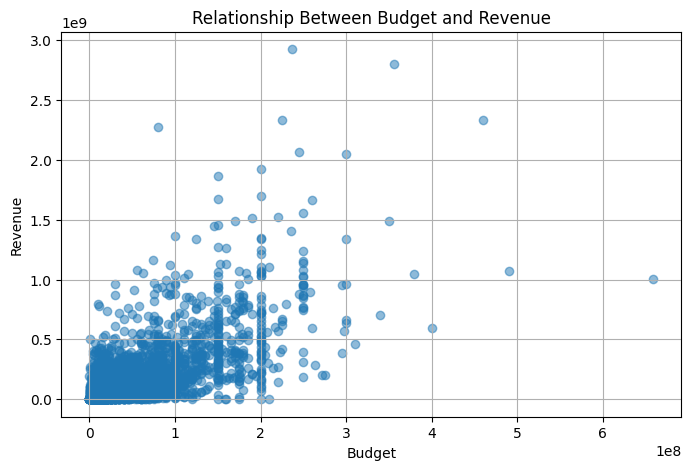

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    financial_df['budget'],
    financial_df['revenue'],
    alpha=0.5
)

plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.title('Relationship Between Budget and Revenue')
plt.grid(True)
plt.show()

Interpretation
- Positive correlation → Higher-budget movies generally tend to have higher revenue.
- Correlation near zero → Little linear relationship.
- Negative correlation → Higher-budget movies tend to have lower revenue.
Important: Correlation does not prove that increasing a movie's budget will guarantee higher revenue.

***Correlation between budget and rating — do bigger budgets buy better movies?***

In [ ]:
budget_rating_df = organized_df[
    (organized_df['budget'] > 0) &
    (organized_df['TMDB_rating'] > 0)
][['id', 'title', 'budget', 'TMDB_rating']]

budget_rating_corr = budget_rating_df['budget'].corr(
    budget_rating_df['TMDB_rating']
)

print("Budget-TMDB Rating Correlation:", round(budget_rating_corr, 3))

Budget-TMDB Rating Correlation: 0.001


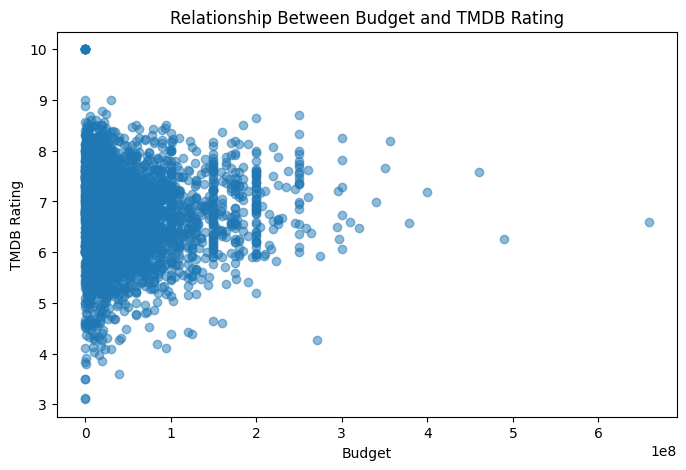

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    budget_rating_df['budget'],
    budget_rating_df['TMDB_rating'],
    alpha=0.5
)

plt.xlabel('Budget')
plt.ylabel('TMDB Rating')
plt.title('Relationship Between Budget and TMDB Rating')
plt.show()

***Average budget/revenue/profit by genre — which genres are most profitable?***

In [ ]:
temp_df = organized_df.iloc[np.where((organized_df['budget'] > 1000) & (organized_df['revenue'] > 1000))]
temp_df.explode('genre').groupby('genre')[['budget', 'revenue', 'calculated_profit']].mean().sort_values(by='calculated_profit', ascending=False)

,budget,revenue,calculated_profit
genre,,,
Animation,6.633942e+07,2.628155e+08,1.964761e+08
Adventure,7.989580e+07,2.654483e+08,1.855525e+08
Family,6.622403e+07,2.328393e+08,1.666153e+08
Science Fiction,7.045470e+07,2.179815e+08,1.475268e+08
Fantasy,6.594339e+07,2.086910e+08,1.427476e+08
Action,6.408697e+07,1.870424e+08,1.229554e+08
Comedy,3.913090e+07,1.300363e+08,9.090537e+07
Music,3.627579e+07,1.153874e+08,7.911164e+07
Romance,2.920353e+07,1.025698e+08,7.336630e+07


***Has average movie budget increased over the years?***

In [ ]:
temp_df = organized_df.iloc[np.where((~organized_df['release_year'].isna()) & (organized_df['budget'] > 1000))]
budget_year = temp_df.groupby('release_year')[['budget']].mean()
budget_year

,budget
release_year,
1920,1.800000e+04
1921,2.500000e+05
1925,9.230000e+05
1926,7.500000e+05
1927,5.300000e+06
...,...
2023,5.825240e+07
2024,4.810584e+07
2025,4.994176e+07


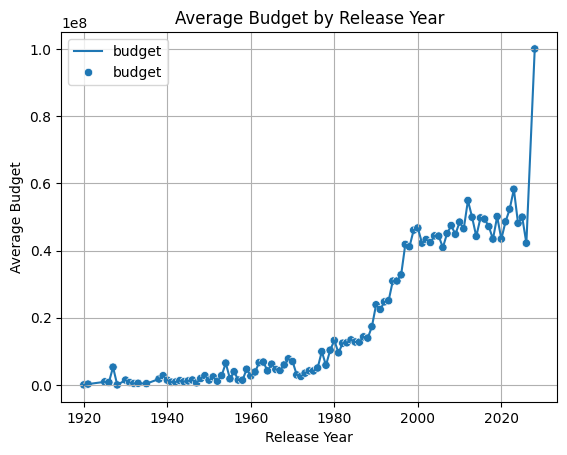

In [ ]:
sns.lineplot(budget_year)
sns.scatterplot(budget_year)
plt.xlabel('Release Year')
plt.ylabel('Average Budget')
plt.title('Average Budget by Release Year')
plt.grid(True)
plt.show()

***Correlation between TMDB rating and IMDb rating — do they broadly agree?***

In [ ]:
temp_df = organized_df.iloc[np.where((organized_df['TMDB_rating'] > 0) & (organized_df['IMDB_rating'] > 0))]
temp_df[['TMDB_rating', 'IMDB_rating']].corr()

,TMDB_rating,IMDB_rating
TMDB_rating,1.000000,0.738917
IMDB_rating,0.738917,1.000000


***Which movies have the biggest TMDB vs IMDb rating gap (and why might that be)?***

In [ ]:
temp_df = organized_df.iloc[np.where((organized_df['TMDB_rating'] > 0) & (organized_df['IMDB_rating'] > 0))]
temp_df['rating_gap'] = abs(temp_df['TMDB_rating'] - temp_df['IMDB_rating'])
temp_df[['id','title','TMDB_rating','TMDB_vote_count','IMDB_rating','IMDB_vote_count','rating_gap']].sort_values(by='rating_gap', ascending=False).head(10)

/tmp/ipykernel_3274/2927314901.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df['rating_gap'] = abs(temp_df['TMDB_rating'] - temp_df['IMDB_rating'])


,id,title,TMDB_rating,TMDB_vote_count,IMDB_rating,IMDB_vote_count,rating_gap
5415,456327,The Last Mountain Pass,1.000,2,8.6,359.0,7.600
961,1472951,Infiltrate,10.000,2,3.9,420.0,6.100
5118,83771,Revolution,0.500,1,6.2,40.0,5.700
5047,440703,Chapeuzinho Vermelho,9.000,1,3.5,29.0,5.500
4329,1592947,Sex,10.000,1,4.7,11.0,5.300
8390,167064,The City Lights,9.500,1,4.3,37.0,5.200
966,1341041,A Haunted Romance,10.000,1,5.0,9.0,5.000
7027,1239447,Sexual Compatibility,8.000,1,3.1,11.0,4.900
7155,368528,Synnöve Solbakken,10.000,1,5.2,23.0,4.800
7362,1134055,Kill Shot,8.037,227,3.3,2296.0,4.737


In [ ]:
temp_df[['TMDB_rating', 'TMDB_vote_count']].corr()

,TMDB_rating,TMDB_vote_count
TMDB_rating,1.000000,0.285086
TMDB_vote_count,0.285086,1.000000


In [ ]:
temp_df[['IMDB_rating', 'IMDB_vote_count']].corr()

,IMDB_rating,IMDB_vote_count
IMDB_rating,1.000000,0.403256
IMDB_vote_count,0.403256,1.000000


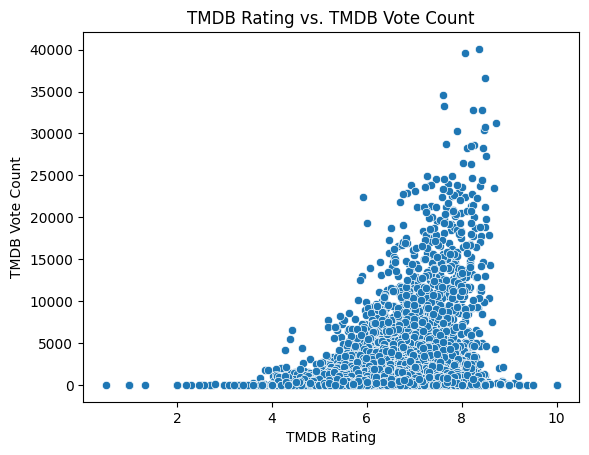

In [ ]:
sns.scatterplot(data=temp_df, x='TMDB_rating', y='TMDB_vote_count')
plt.xlabel('TMDB Rating')
plt.ylabel('TMDB Vote Count')
plt.title('TMDB Rating vs. TMDB Vote Count')
plt.show()

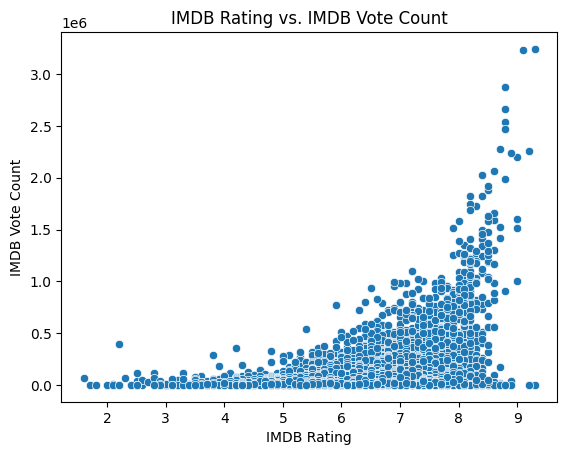

In [ ]:
sns.scatterplot(data=temp_df, x='IMDB_rating', y='IMDB_vote_count')
plt.xlabel('IMDB Rating')
plt.ylabel('IMDB Vote Count')
plt.title('IMDB Rating vs. IMDB Vote Count')
plt.show()

Answer: Movies with higher TMDB and IMDB ratings tend to have somewhat higher vote counts, but the relationship is weak and has many exceptions.

***Does vote count correlate with rating (popularity bias)?***

In [ ]:
temp_df = organized_df.iloc[
    np.where(
        (organized_df['TMDB_rating'] > 0) &
        (organized_df['TMDB_rating'].notna()) &
        (organized_df['TMDB_vote_count'].notna()) &
        (organized_df['IMDB_rating'] > 0) &
        (organized_df['IMDB_rating'].notna()) &
        (organized_df['IMDB_vote_count'].notna())
    )
]
print(temp_df[['TMDB_rating', 'TMDB_vote_count']].corr())
print(temp_df[['IMDB_rating','IMDB_vote_count']].corr())

                 TMDB_rating  TMDB_vote_count
TMDB_rating         1.000000         0.285086
TMDB_vote_count     0.285086         1.000000
                 IMDB_rating  IMDB_vote_count
IMDB_rating         1.000000         0.403256
IMDB_vote_count     0.403256         1.000000


**Answer:**<br> TMDB and IMDb ratings both show a positive correlation with vote counts. IMDb has a stronger relationship (0.403) than TMDB (0.285), suggesting that movies with more votes tend to have somewhat higher ratings. However, the correlations are not strong enough to conclude that popularity alone determines ratings.

*"Hidden gems": high rating but low popularity/vote count*

In [ ]:
hidden_gems = organized_df[
    (organized_df['IMDB_rating'] >= 7.5) &
    (organized_df['IMDB_vote_count'] >= 100) &
    (organized_df['popularity'] <= organized_df['popularity'].quantile(0.25))
]

hidden_gems[
    ['id', 'title', 'popularity', 'IMDB_rating', 'IMDB_vote_count']
].sort_values(
    by='IMDB_rating',
    ascending=False
).head(10)

,id,title,popularity,IMDB_rating,IMDB_vote_count
8277,1163258,12th Fail,4.1411,8.7,177797.0
7025,17663,Anne of Green Gables,5.1779,8.6,24871.0
5807,803,Night and Fog,5.3886,8.6,23756.0
6980,1507573,National Theatre Live: The Fifth Step,5.1847,8.4,189.0
5698,1448497,Ocean with David Attenborough,5.3460,8.4,5734.0
8263,820232,Demon Slayer: Kimetsu no Yaiba - Sibling's Bond,5.0663,8.4,5247.0
7283,821,Judgment at Nuremberg,4.8879,8.3,98646.0
7326,3780,Red Beard,5.6155,8.3,23817.0
8402,13187,A Charlie Brown Christmas,4.6917,8.3,51009.0
6871,531,The Wrong Trousers,4.8041,8.3,64166.0


***"Overrated": high popularity but mediocre rating***

In [ ]:
overrated = organized_df[
    (organized_df['IMDB_rating'].between(5.0, 6.5)) &
    (organized_df['IMDB_vote_count'] >= 100) &
    (organized_df['popularity'] >= organized_df['popularity'].quantile(0.75))
]

overrated[
    ['id', 'title', 'popularity', 'IMDB_rating', 'IMDB_vote_count']
].sort_values(
    by='popularity',
    ascending=False
).head(10)

,id,title,popularity,IMDB_rating,IMDB_vote_count
2,1288445,Mutiny,392.0104,5.7,21710.0
6,1516698,The Last Sunrise,250.2477,5.6,6341.0
9,860508,The Whisper Man,213.5041,6.2,56484.0
12,1375646,Colony,204.1842,6.5,16512.0
11,1232569,Pinocchio: Unstrung,170.4168,5.4,4076.0
16,1315772,Minions & Monsters,160.3543,6.3,33115.0
17,1108427,Moana,155.1311,5.8,18041.0
20,1130948,Rosebush Pruning,118.9504,5.1,2525.0
24,1275779,Disclosure Day,103.6271,6.4,158552.0
26,1284465,The Death of Robin Hood,103.1736,6.0,20230.0


***Which genres are most profitable / highest ROI?***

In [ ]:
temp_df = organized_df.iloc[
    np.where(
        (organized_df['budget'] > 1000) &
        (organized_df['revenue'] > 1000) &
        (organized_df['calculated_profit'].notna())
    )
][
    ['id', 'title', 'genre', 'budget', 'revenue', 'calculated_profit']
].copy()

temp_df['ROI'] = temp_df['calculated_profit'] / temp_df['budget']

genre_analysis = (
    temp_df
    .explode('genre')
    .groupby('genre')
    .agg(
        average_profit=('calculated_profit', 'mean'),
        average_ROI=('ROI', 'mean'),
        movie_count=('id', 'count')
    )
)

genre_analysis = genre_analysis[
    genre_analysis['movie_count'] >= 20
].sort_values(
    by='average_ROI',
    ascending=False
)

genre_analysis

,average_profit,average_ROI,movie_count
genre,,,
Mystery,5.556730e+07,43.508659,435
Horror,4.702418e+07,34.103965,663
Animation,1.964761e+08,6.129475,374
Music,7.911164e+07,5.790312,107
Thriller,5.540335e+07,5.432962,1395
Family,1.666153e+08,4.480026,554
Romance,7.336630e+07,4.354170,681
Comedy,9.090537e+07,4.164691,1488
Drama,5.201401e+07,4.105432,1958


***How has genre popularity shifted over the years (e.g., is horror/superhero growing)?***

In [ ]:
top_10_genres =  organized_df.explode('genre')['genre'].value_counts().head(10).index.tolist()

genre_year_count = (
    organized_df
    .dropna(subset=['release_year'])
    .explode('genre')
    .groupby(['release_year', 'genre'])['id']
    .count()
    .reset_index(name='movie_count')
)

top_10_trends = genre_year_count[
    genre_year_count['genre'].isin(top_10_genres)
]

In [ ]:
top_10_trends

,release_year,genre,movie_count
0,1908,Comedy,1
1,1908,Fantasy,1
2,1910,Comedy,1
3,1910,Fantasy,1
4,1912,Drama,2
...,...,...,...
1466,2028,Fantasy,1
1469,2028,Thriller,3
1470,2029,Action,1
1471,2029,Adventure,1


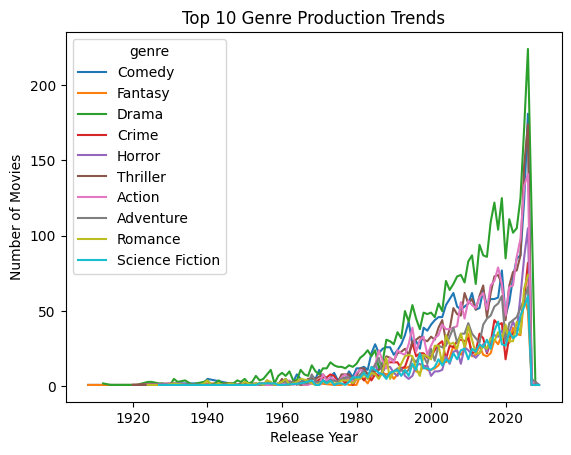

In [ ]:
sns.lineplot(
    data=top_10_trends,
    x='release_year',
    y='movie_count',
    hue='genre'
)

plt.title('Top 10 Genre Production Trends')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.show()

In [ ]:
heatmap_data = top_10_trends.pivot(
    index='genre',
    columns='release_year',
    values='movie_count'
).fillna(0)
heatmap_data

release_year,1908,1910,1912,1914,1920,1921,1922,1924,1925,1926,...,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029
genre,,,,,,,,,,,,,,,,,,,,,
Action,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,47.0,66.0,67.0,86.0,98.0,133.0,141.0,2.0,3.0,1.0
Adventure,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,30.0,42.0,44.0,46.0,52.0,58.0,66.0,5.0,0.0,1.0
Comedy,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,47.0,56.0,72.0,85.0,87.0,124.0,181.0,4.0,0.0,0.0
Crime,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,18.0,33.0,35.0,39.0,44.0,58.0,82.0,1.0,3.0,0.0
Drama,0.0,0.0,2.0,1.0,1.0,1.0,0.0,3.0,3.0,0.0,...,85.0,111.0,102.0,105.0,125.0,172.0,224.0,0.0,2.0,0.0
Fantasy,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,35.0,29.0,39.0,35.0,34.0,59.0,50.0,3.0,1.0,0.0
Horror,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,31.0,36.0,43.0,37.0,60.0,86.0,105.0,1.0,0.0,0.0
Romance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,41.0,30.0,30.0,43.0,35.0,65.0,74.0,0.0,0.0,0.0
Science Fiction,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,27.0,36.0,32.0,34.0,47.0,53.0,60.0,1.0,0.0,1.0


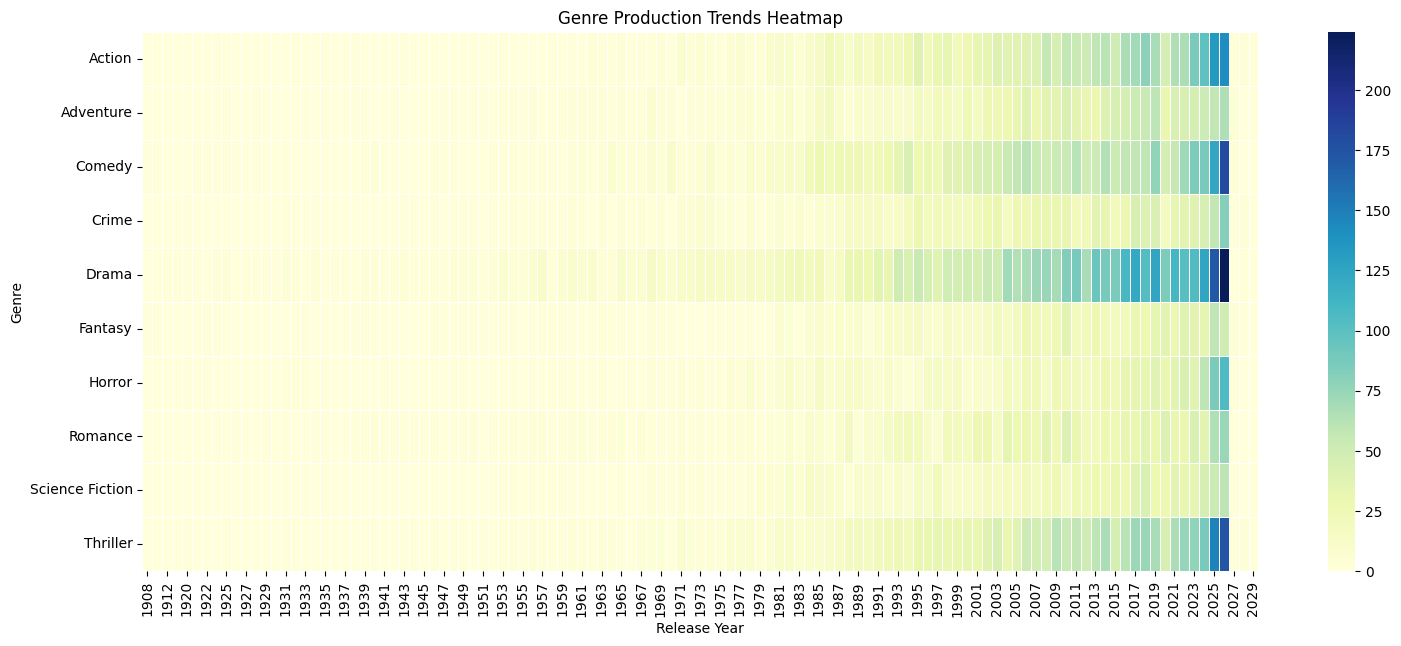

In [ ]:
plt.figure(figsize=(18, 7))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Genre Production Trends Heatmap')
plt.xlabel('Release Year')
plt.ylabel('Genre')
plt.show()

**Answer**<br>
Genre popularity has generally increased over the years, particularly from the 1980s onward. Drama and Comedy show strong growth in movie production, while Action, Thriller, and Science Fiction also display increasing trends. Horror has grown over time, with fluctuations in yearly production.<br>
**Conclusion:**<br> The dataset suggests that movie production across major genres has expanded, especially in recent decades. However, the graph measures the number of movies produced, not audience popularity or viewing preferences. Recent years may contain incomplete data.

***Do movies with multiple genres perform differently than single-genre movies?***

In [ ]:
temp_df = organized_df.copy()
temp_df['genre_type'] = np.where(
    temp_df['genre'].apply(len) == 1,
    'Single Genre',
    'Multiple Genres'
)

In [ ]:
temp_df.groupby('genre_type')[['TMDB_rating', 'IMDB_rating', 'popularity','calculated_profit']].mean()

,TMDB_rating,IMDB_rating,popularity,calculated_profit
genre_type,,,,
Multiple Genres,6.436342,6.441692,11.315601,9.252888e+07
Single Genre,4.836481,6.356953,8.165784,4.571266e+07


**Answer**<br>
Movies with multiple genres have higher average TMDB ratings (6.43), IMDb ratings (6.44), popularity (10.71), and calculated profit (85.44 million) compared to single-genre movies, which have averages of 5.14, 6.39, 8.20, and 44.57 million, respectively.<br>
**Conclusion:**<br> In this dataset, multiple-genre movies show higher average ratings, popularity, and calculated profit than single-genre movies. However, this is an association and does not establish that having multiple genres directly causes better performance.

***Average runtime by genre***

In [ ]:
organized_df.explode('genre').groupby('genre')['runtime'].mean().sort_values(ascending=False)

,runtime
genre,
History,123.577428
War,123.562500
Western,118.547826
Crime,109.198255
Action,107.633836
Drama,106.394069
Thriller,105.697024
Adventure,105.594460
Romance,104.823578


***Number of movies released per year — full trend, not just top 10***

In [ ]:
temp_df = organized_df[~organized_df['release_year'].isna()]
movies_per_year = temp_df.groupby('release_year')['id'].size().sort_index().reset_index(name='no_of_movies')
movies_per_year

,release_year,no_of_movies
0,1908,1
1,1910,1
2,1912,2
3,1914,2
4,1918,1
...,...,...
109,2025,458
110,2026,629
111,2027,8
112,2028,6


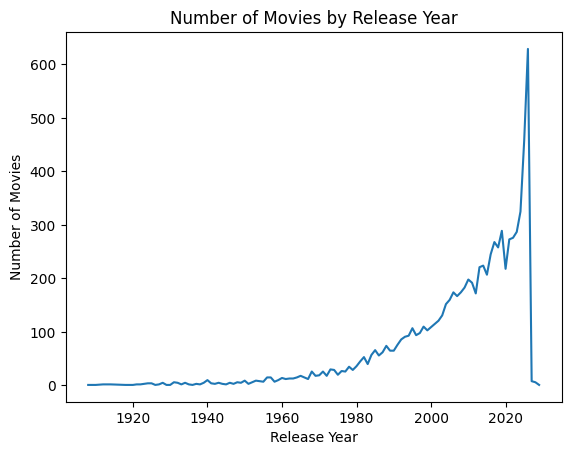

In [ ]:
sns.lineplot(data=movies_per_year, x='release_year', y='no_of_movies')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.title('Number of Movies by Release Year')
plt.show()

***Average rating trend over years — are movies rated better/worse over time?***

In [ ]:
temp_df = organized_df[~organized_df['release_year'].isna() & organized_df['IMDB_rating'].notna() & organized_df['TMDB_rating'].notna()]
rating_trend = temp_df.groupby('release_year')[['IMDB_rating', 'TMDB_rating']].mean()
rating_trend

,IMDB_rating,TMDB_rating
release_year,,
1908,5.200000,6.000000
1910,5.000000,7.000000
1912,6.600000,0.000000
1914,4.600000,0.000000
1920,8.000000,7.932000
...,...,...
2023,6.286590,6.617667
2024,6.184466,6.617330
2025,5.950943,6.530599


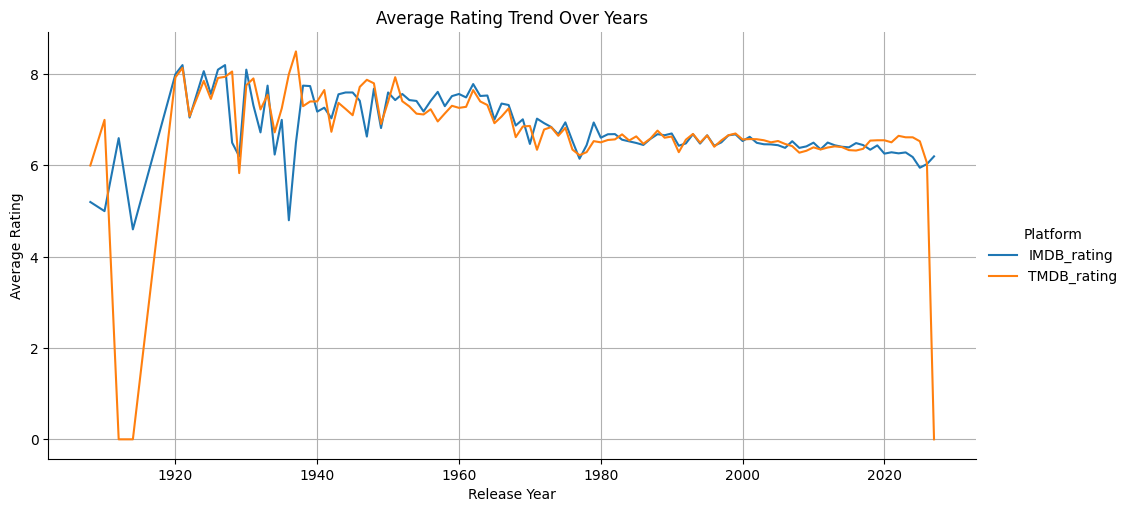

In [ ]:
rating_trend_reset = rating_trend.reset_index()

rating_trend_melted = rating_trend_reset.melt(
    id_vars='release_year',
    var_name='Platform',
    value_name='Average Rating'
)

sns.relplot(
    data=rating_trend_melted,
    x='release_year',
    y='Average Rating',
    hue='Platform',
    kind='line',
    height=5,
    aspect=2
)

plt.xlabel('Release Year')
plt.ylabel('Average Rating')
plt.title('Average Rating Trend Over Years')
plt.grid(True)
plt.show()

<Axes: xlabel='release_year', ylabel='IMDB_rating'>

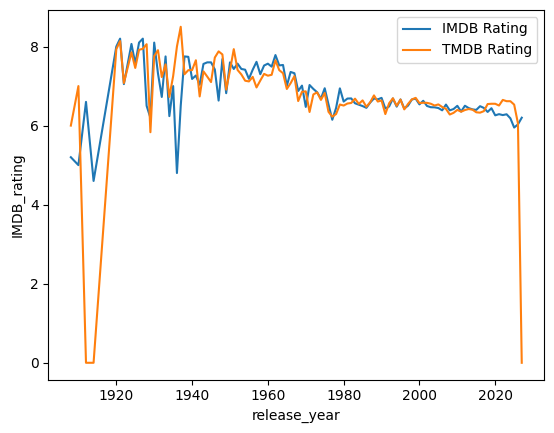

In [ ]:
sns.lineplot(data=rating_trend, x=rating_trend.index, y='IMDB_rating', label='IMDB Rating')
sns.lineplot(data=rating_trend, x=rating_trend.index, y='TMDB_rating', label='TMDB Rating')

***Average runtime trend over years***

In [ ]:
temp_df = organized_df[~organized_df['release_year'].isna() & organized_df['runtime'].notna() & organized_df['runtime'] > 0]
runtime_trend = temp_df.groupby('release_year')['runtime'].mean().reset_index()
runtime_trend

,release_year,runtime
0,1908,1.000000
1,1912,42.000000
2,1920,77.000000
3,1924,45.000000
4,1925,85.000000
...,...,...
98,2022,100.428571
99,2023,103.865248
100,2024,102.423529
101,2025,98.811159


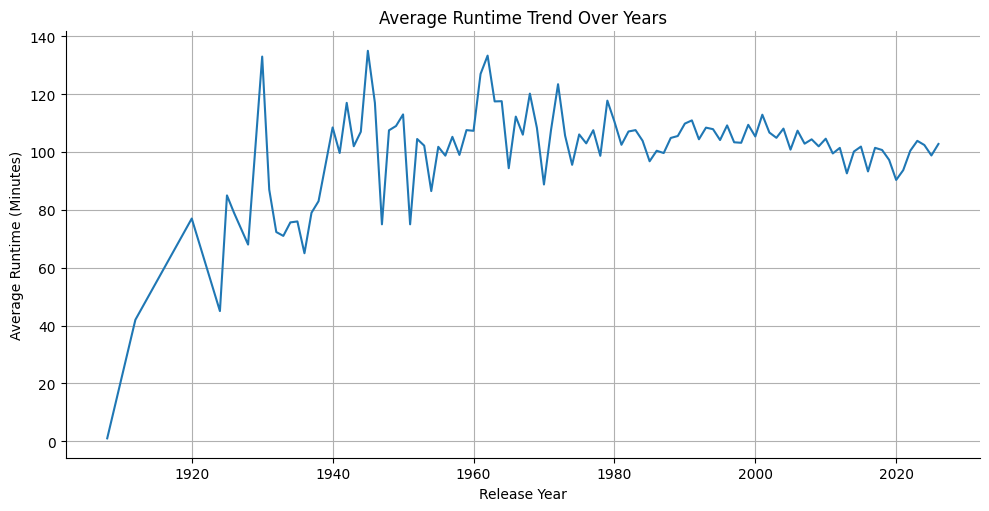

In [ ]:
sns.relplot(
    data=runtime_trend,
    x='release_year',
    y='runtime',
    kind='line',
    height=5,
    aspect=2
)

plt.xlabel('Release Year')
plt.ylabel('Average Runtime (Minutes)')
plt.title('Average Runtime Trend Over Years')
plt.grid(True)
plt.show()

***Best release month by average revenue***

In [ ]:
temp_df = organized_df.copy()

temp_df['release_month'] = temp_df['release_date'].dropna().dt.month_name()
revenue_month_df = temp_df[temp_df['revenue'].notna() & temp_df['revenue'] > 0].groupby('release_month')['revenue'].mean().sort_values(ascending=False).reset_index()
revenue_month_df

,release_month,revenue
0,June,1.893340e+08
1,May,1.886250e+08
2,July,1.641498e+08
3,November,1.292302e+08
4,December,1.290536e+08
5,April,1.274862e+08
6,February,9.520859e+07
7,October,9.373149e+07
8,March,8.514932e+07
9,January,6.765410e+07


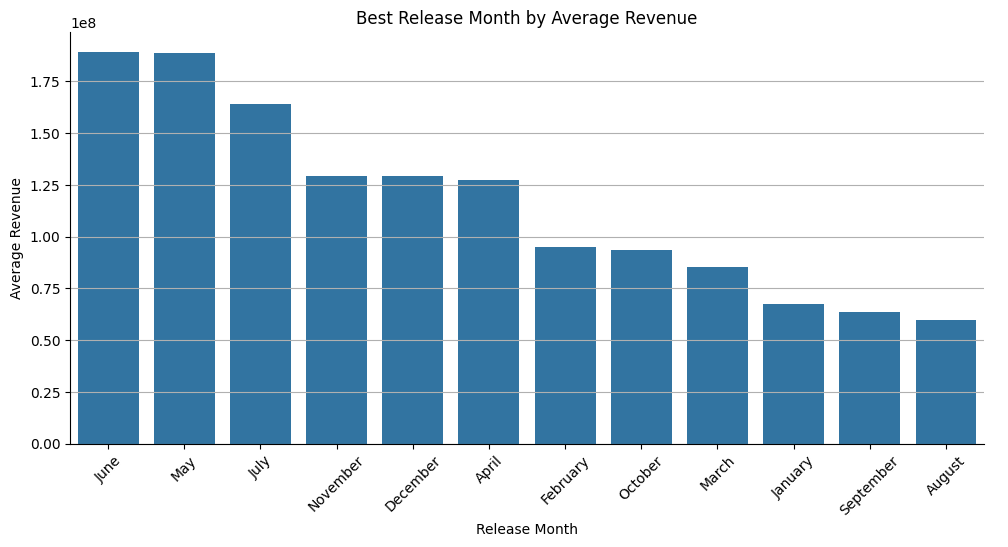

In [ ]:
sns.catplot(data=revenue_month_df, x='release_month', y='revenue', kind='bar', height=5, aspect=2)
plt.xlabel('Release Month')
plt.ylabel('Average Revenue')
plt.title('Best Release Month by Average Revenue')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()

***Movies per decade — golden eras by volume or by rating***

In [ ]:
temp_df = organized_df[organized_df['release_year'].notna()].copy()

bin_edges = np.arange(1900, 2040, 10)
bin_labels = [f'{i}s' for i in range (1900, 2030, 10)]
temp_df['decade'] = pd.cut(temp_df['release_year'], bins=bin_edges, labels=bin_labels, right=False)
decade_volume = temp_df.groupby('decade')['id'].size().sort_index().reset_index(name='volume')
decade_volume

/tmp/ipykernel_3274/2472501471.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decade_volume = temp_df.groupby('decade')['id'].size().sort_index().reset_index(name='volume')


,decade,volume
0,1900s,1
1,1910s,6
2,1920s,22
3,1930s,32
4,1940s,46
5,1950s,89
6,1960s,156
7,1970s,259
8,1980s,554
9,1990s,923


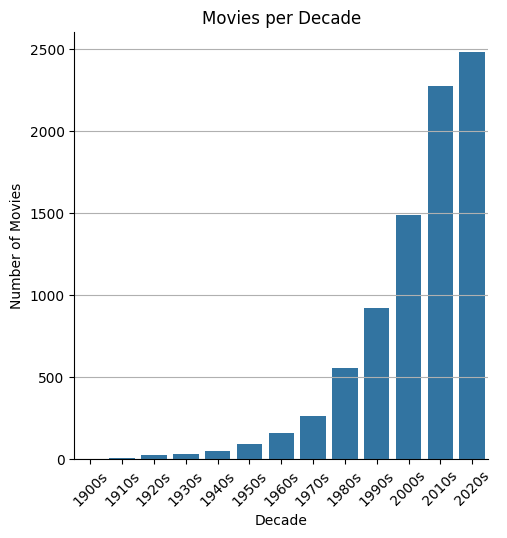

In [ ]:
sns.catplot(data=decade_volume, x='decade', y='volume', kind='bar')

plt.xlabel('Decade')
plt.xticks(rotation=45)
plt.ylabel('Number of Movies')
plt.title('Movies per Decade')
plt.grid(True, axis='y')
plt.show()

***Top production companies by movie count and by average rating***

In [ ]:
temp_df = organized_df[
    organized_df['production_companies'].notna() &
    organized_df['production_companies'].apply(lambda x : x != ['Unknown']) &
    organized_df['IMDB_rating'].notna()].copy()
comapny_analysis_df = temp_df.explode('production_companies').groupby('production_companies')[
    ['id', 'IMDB_rating']
    ].agg({'id': 'size', 'IMDB_rating': 'mean'}).reset_index().rename(columns={'id':'no_of_movies', 'IMDB_rating':'avg_IMDB_rating'}).sort_values(by='no_of_movies', ascending=False)

comapny_analysis_df

,production_companies,no_of_movies,avg_IMDB_rating
8145,Universal Pictures,381,6.448294
8427,Warner Bros. Pictures,347,6.696830
1682,Columbia Pictures,317,6.542587
5764,Paramount Pictures,293,6.607167
38,20th Century Fox,238,6.486555
...,...,...,...
3,1-2-3 Production,1,5.700000
2,01douga,1,6.800000
1,+Sixty Six,1,4.700000
0,#littlesecretfilm,1,4.900000


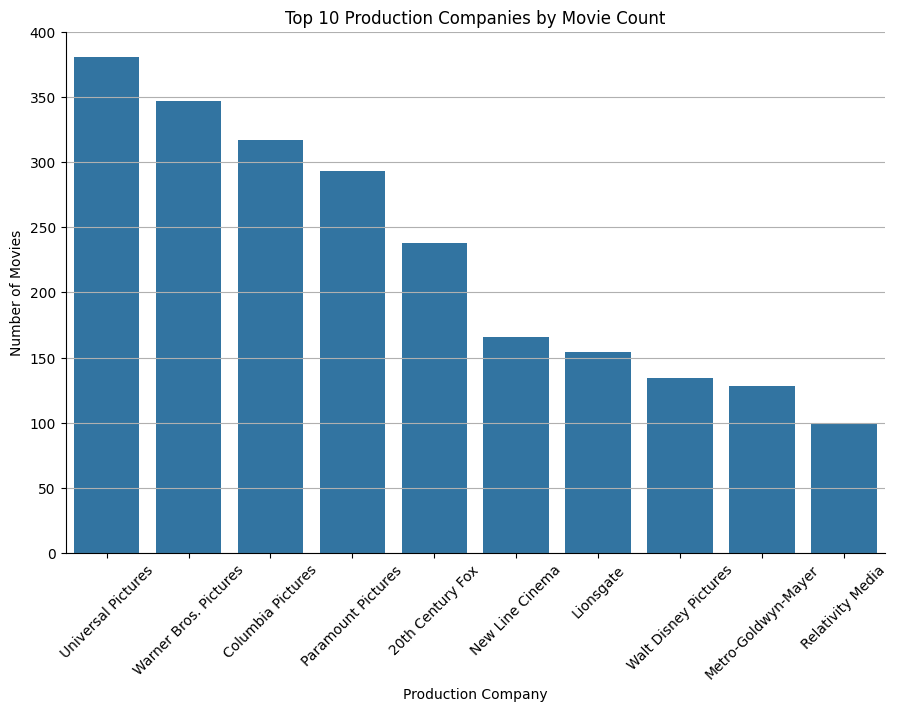

In [ ]:
top_10_companies = comapny_analysis_df.head(10)
sns.catplot(data=top_10_companies, x='production_companies', y='no_of_movies', kind='bar', height=6, aspect=1.5)
plt.xlabel('Production Company')
plt.xticks(rotation=45)
plt.ylabel('Number of Movies')
plt.title('Top 10 Production Companies by Movie Count')
plt.grid(True, axis='y')
plt.show()

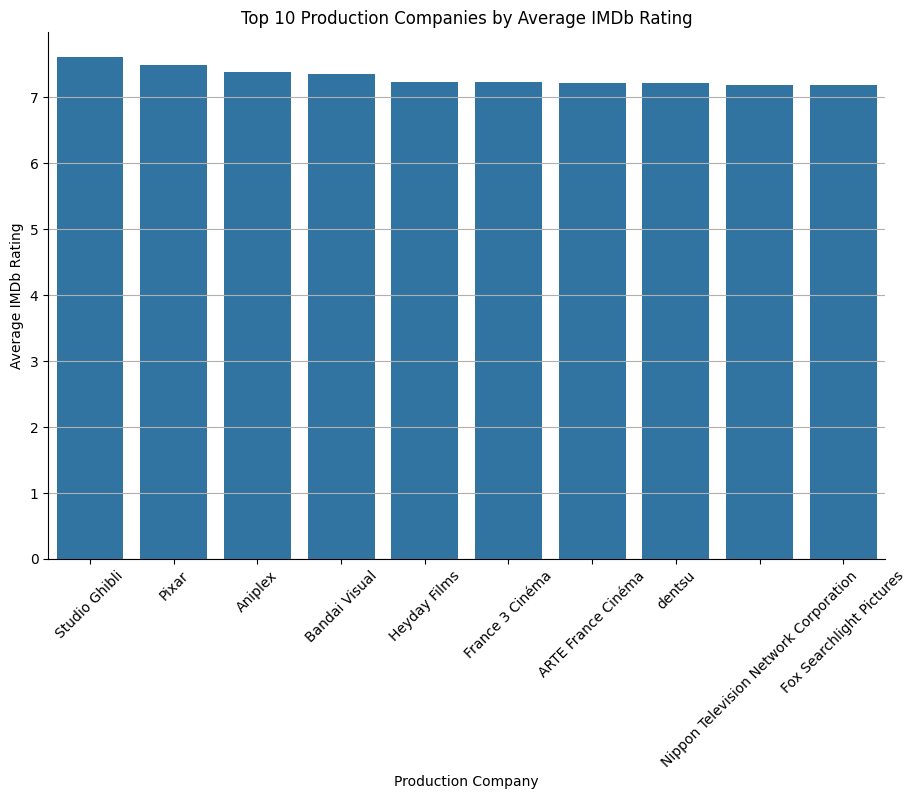

In [ ]:
company_rating_df = (
    comapny_analysis_df[
        comapny_analysis_df['no_of_movies'] >= 20
    ]
    .sort_values(by='avg_IMDB_rating', ascending=False)
)

top_10_rating_companies = company_rating_df.head(10)

sns.catplot(data=top_10_rating_companies, x='production_companies', y='avg_IMDB_rating', kind='bar', height=6, aspect=1.5)
plt.xlabel('Production Company')
plt.xticks(rotation=45)
plt.ylabel('Average IMDb Rating')
plt.title('Top 10 Production Companies by Average IMDb Rating')
plt.grid(True, axis='y')
plt.show()

***Top production companies by total revenue***

In [ ]:
temp_df = organized_df[
    organized_df['production_companies'].notna() &
    organized_df['production_companies'].apply(lambda x : x != ['Unknown']) &
    organized_df['revenue'].notna() &
    organized_df['revenue'] > 0].copy()

top_10_companies = temp_df.explode('production_companies').groupby('production_companies')['revenue'].sum().sort_values(ascending=False).head(10).reset_index(name='total_revenue')
top_10_companies

,production_companies,total_revenue
0,Universal Pictures,28519431853
1,Columbia Pictures,25101402158
2,Warner Bros. Pictures,22964876814
3,Paramount Pictures,21022153824
4,Marvel Studios,16889030931
5,20th Century Fox,16472382182
6,Walt Disney Pictures,12585481106
7,New Line Cinema,9945050552
8,DreamWorks Animation,9399076961
9,Illumination,8324215923


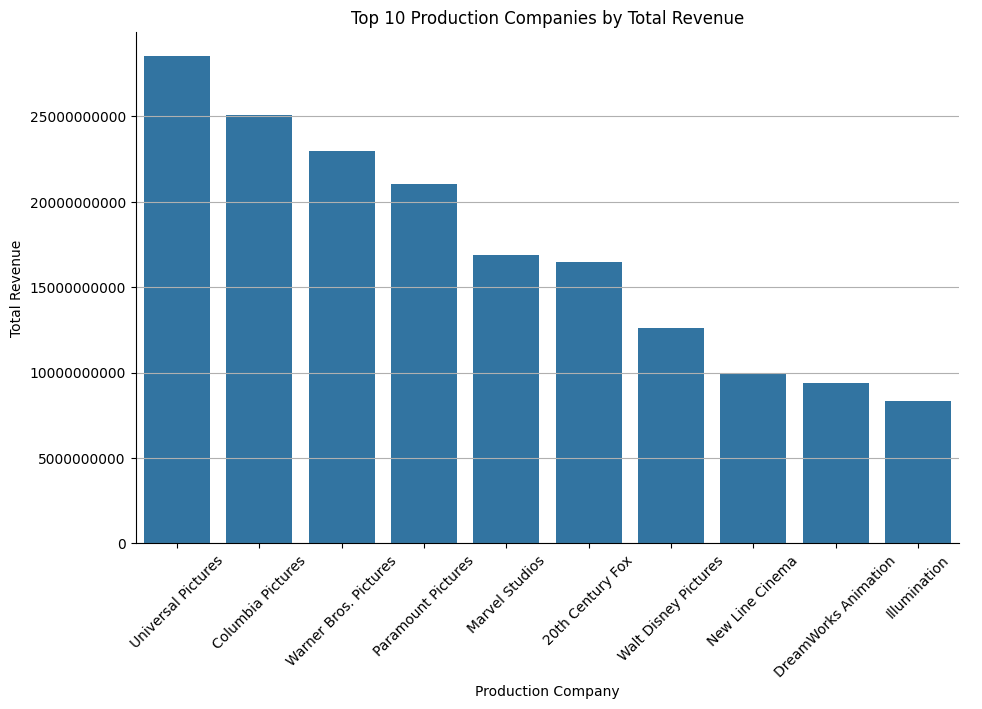

In [ ]:
sns.catplot(data=top_10_companies, x='production_companies', y='total_revenue', kind='bar', height=6, aspect=1.5)
plt.xlabel('Production Company')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel('Total Revenue')
plt.title('Top 10 Production Companies by Total Revenue')
plt.grid(True, axis='y')
plt.show()

***Top production countries by output and by average rating***

In [ ]:
temp_df = organized_df[
    organized_df['production_countries'].notna() &
    organized_df['production_countries'].apply(lambda x : x != ['Unknown']) &
    organized_df['IMDB_rating'].notna() &
    organized_df['IMDB_rating'] > 0].copy()

top_10_countries = temp_df.explode('production_countries').groupby('production_countries')[['id', 'IMDB_rating']].agg({'id': 'size', 'IMDB_rating': 'mean'}).reset_index().rename(columns={'id':'count'}).sort_values(by='count', ascending=False).head(10)
top_10_countries

,production_countries,count,IMDB_rating
112,United States of America,5471,6.419686
111,United Kingdom,1111,6.552835
35,France,652,6.603528
37,Germany,438,6.482648
54,Japan,429,6.757343
17,Canada,403,6.089826
99,Spain,204,6.240686
52,Italy,203,6.422660
19,China,201,6.389055
43,Hong Kong,194,6.515464


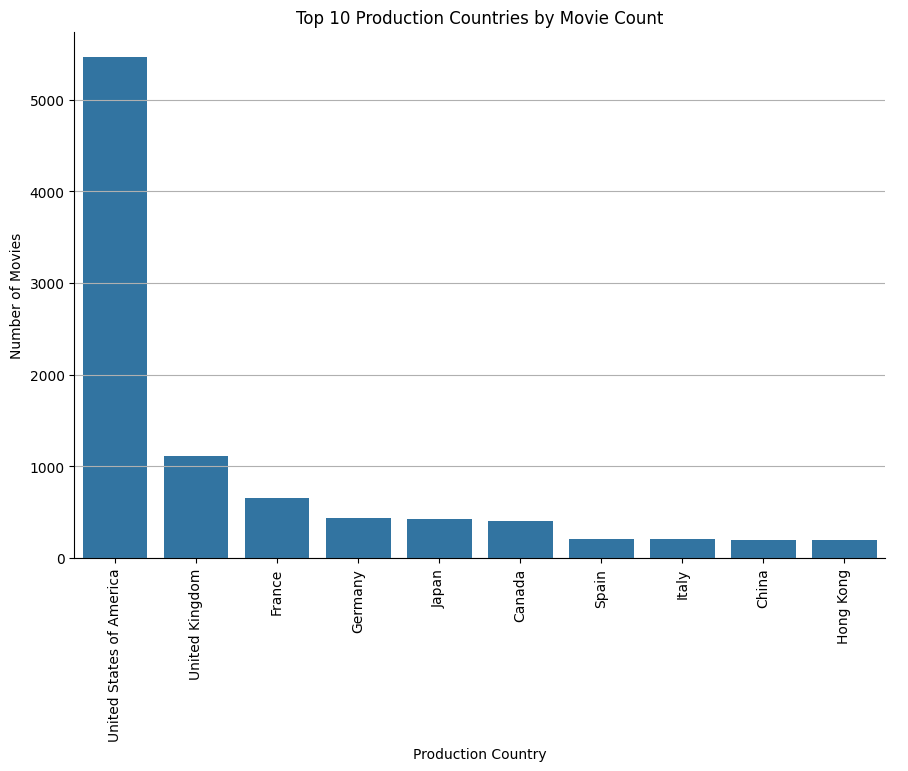

In [ ]:
sns.catplot(data=top_10_countries, x='production_countries', y='count', kind='bar', height=6, aspect=1.5)
plt.xlabel('Production Country')
plt.xticks(rotation=90)
plt.ylabel('Number of Movies')
plt.title('Top 10 Production Countries by Movie Count')
plt.grid(True, axis='y')
plt.show()

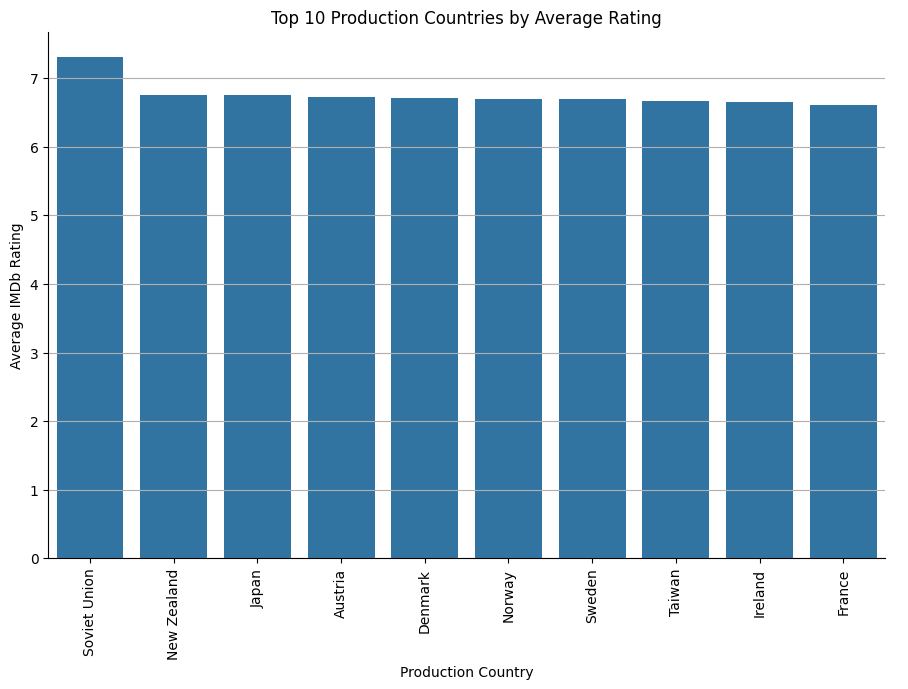

In [ ]:
country_analysis_df = (
    temp_df
    .explode('production_countries')
    .groupby('production_countries')[['id', 'IMDB_rating']]
    .agg({'id': 'size', 'IMDB_rating': 'mean'})
    .reset_index()
    .rename(columns={'id': 'count'})
)

country_rating_df = (
    country_analysis_df[
        country_analysis_df['count'] >= 20
    ]
    .sort_values(by='IMDB_rating', ascending=False)
    .head(10)
)

sns.catplot(
    data=country_rating_df,
    x='production_countries',
    y='IMDB_rating',
    kind='bar',
    height=6,
    aspect=1.5
)

plt.xlabel('Production Country')
plt.xticks(rotation=90)
plt.ylabel('Average IMDb Rating')
plt.title('Top 10 Production Countries by Average Rating')
plt.grid(True, axis='y')
plt.show()

**Answer**<br>
The United States has the highest movie output, with 6,659 movies, followed by the United Kingdom and France. For average IMDb rating, Denmark, Austria, and Japan appear among the highest-rated production countries, with ratings close to 6.8–6.9.<br>
**Conclusion:**<br> The United States dominates movie production by volume, while some countries with lower production output show higher average IMDb ratings. This comparison does not establish that a country's production industry causes higher ratings.

In [ ]:
temp_df = organized_df[
    (organized_df['original_language'] != 'Unknown') &
    (organized_df['original_language'] != 'English') &
    (organized_df['IMDB_rating'].notna())
].copy()

lang_analysis = (
    temp_df
    .groupby('original_language')
    .agg(
        avg_IMDB_rating=('IMDB_rating', 'mean'),
        movie_count=('id', 'count')
    )
    .reset_index()
)

lang_analysis = (
    lang_analysis[lang_analysis['movie_count'] >= 20]
    .sort_values('avg_IMDB_rating', ascending=False)
)

lang_analysis

,original_language,avg_IMDB_rating,movie_count
55,No Language,7.237838,37
42,Latin,6.987805,41
37,Japanese,6.824623,398
87,Vietnamese,6.678571,28
25,German,6.666013,153
77,Swedish,6.665385,52
21,French,6.654342,357
29,Hindi,6.605263,38
41,Korean,6.589103,156
30,Hungarian,6.563636,33


In [ ]:
revenue_lang_analysis = (
    organized_df[
        (organized_df['original_language'] != 'Unknown') &
        (organized_df['original_language'] != 'English') &
        (organized_df['revenue'] > 0)
    ]
    .groupby('original_language')
    .agg(
        avg_revenue=('revenue', 'mean'),
        movie_count=('id', 'count')
    )
    .reset_index()
)

revenue_lang_analysis = (
    revenue_lang_analysis[
        revenue_lang_analysis['movie_count'] >= 20
    ]
    .sort_values('avg_revenue', ascending=False)
)

revenue_lang_analysis

,original_language,avg_revenue,movie_count
68,Thai,1.800972e+08,22
41,Mandarin,1.794502e+08,94
2,Arabic,1.631709e+08,23
54,Russian,1.377132e+08,117
61,Spanish,1.264983e+08,373
63,Swedish,1.187079e+08,24
19,French,1.057994e+08,226
32,Italian,1.017169e+08,107
50,Portuguese,1.001731e+08,48
22,German,9.636550e+07,96


**Answer**<br>
The analysis shows that original language is associated with differences in average IMDb ratings and revenue. Japanese-language movies have a relatively high average IMDb rating (6.87), while Mandarin-language movies have the highest average revenue (approximately 184.89 million) among the languages shown.<br>
**Conclusion:**<br> Language groups show variations in average ratings and revenue, but a direct correlation cannot be established because original language is a categorical variable. Revenue results may also be influenced by the number of movies and individual blockbuster films.

***Is English-language dominance shrinking or growing over the years?***

In [ ]:
temp_df = organized_df[
    organized_df['release_year'].notna() &
    (organized_df['original_language'] != 'Unknown')
].copy()

yearly_language = (
    temp_df
    .groupby('release_year')
    .agg(
        total_movies=('id', 'size'),
        english_movies=('original_language', lambda x: (x == 'English').sum())
    )
    .reset_index()
)

yearly_language['english_percentage'] = (
    yearly_language['english_movies'] /
    yearly_language['total_movies'] * 100
)

yearly_language

,release_year,total_movies,english_movies,english_percentage
0,1908,1,0,0.000000
1,1912,1,0,0.000000
2,1914,2,0,0.000000
3,1920,1,0,0.000000
4,1921,2,0,0.000000
...,...,...,...,...
107,2025,445,237,53.258427
108,2026,603,290,48.092869
109,2027,8,8,100.000000
110,2028,6,6,100.000000


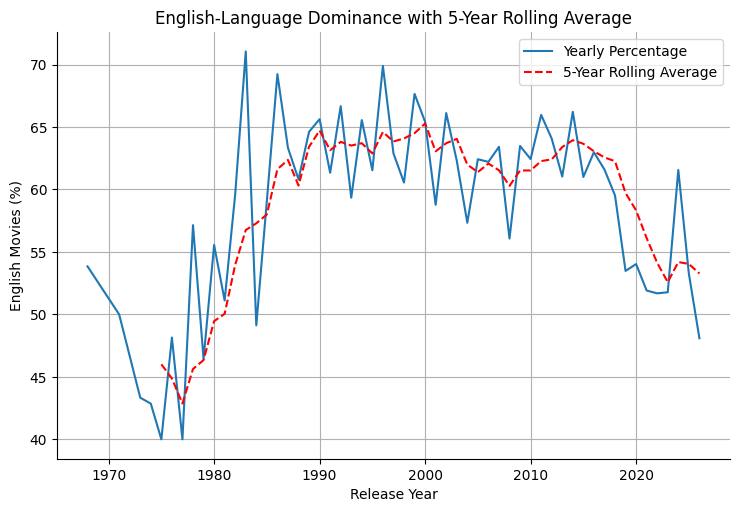

In [ ]:
yearly_language_filtered = yearly_language[
    yearly_language['total_movies'] >= 20
]

yearly_language_filtered = yearly_language_filtered.sort_values('release_year').copy()

yearly_language_filtered['rolling_avg'] = (
    yearly_language_filtered['english_percentage']
    .rolling(window=5)
    .mean()
)



sns.relplot(
    data=yearly_language_filtered,
    x='release_year',
    y='english_percentage',
    kind='line',
    label='Yearly Percentage',
    height=5,
    aspect=1.5
)

sns.lineplot(
    data=yearly_language_filtered,
    x='release_year',
    y='rolling_avg',
    label='5-Year Rolling Average',
    linestyle='--',
    color='red'
)

plt.xlabel('Release Year')
plt.ylabel('English Movies (%)')
plt.title('English-Language Dominance with 5-Year Rolling Average')
plt.grid(True)
plt.show()

<b>Answer</b><br>
English-language dominance grew from the 1980s to the late 1990s, reaching approximately 65–70%. It remained relatively stable through the 2000s and 2010s, but shows a declining trend after around 2018, falling to approximately 48% in 2026.
<br>
**Conclusion:**<br> English-language dominance appears to be shrinking in recent years, although the dataset's recent-year coverage may be incomplete.

## ADDITIONAL VISUALIZATIONS

*Set a consistent visual theme for the remaining charts*

In [ ]:
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

*Distribution of TMDB and IMDb ratings*

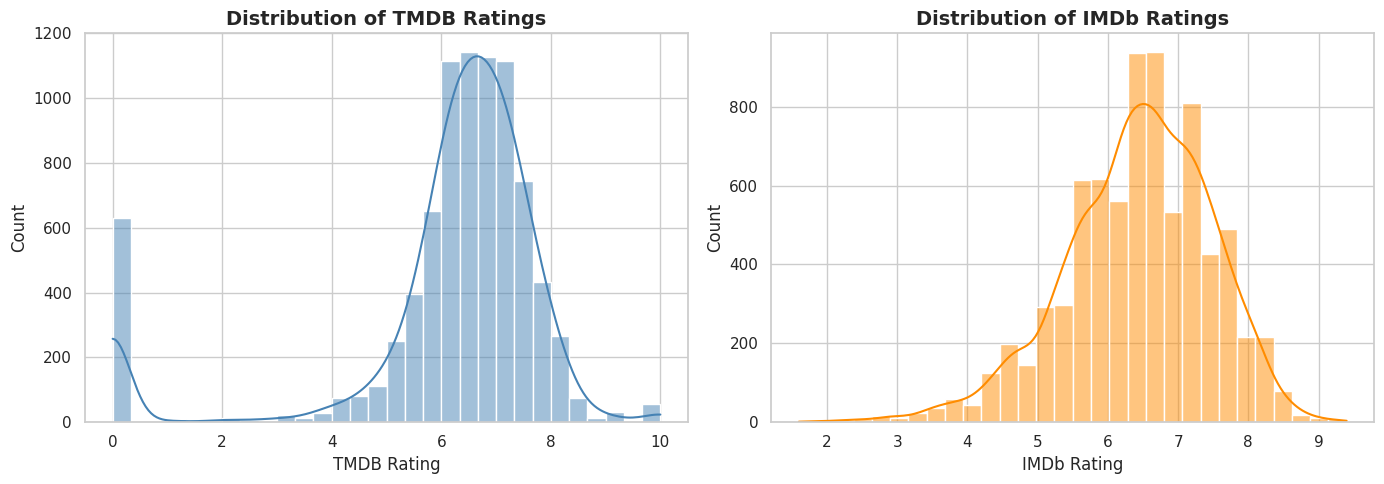

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(organized_df['TMDB_rating'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of TMDB Ratings')
axes[0].set_xlabel('TMDB Rating')
sns.histplot(organized_df['IMDB_rating'].dropna(), bins=30, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of IMDb Ratings')
axes[1].set_xlabel('IMDb Rating')
plt.tight_layout()
plt.show()

*Distribution of movie runtime (excluding 0 and extreme outliers above 400 min)*

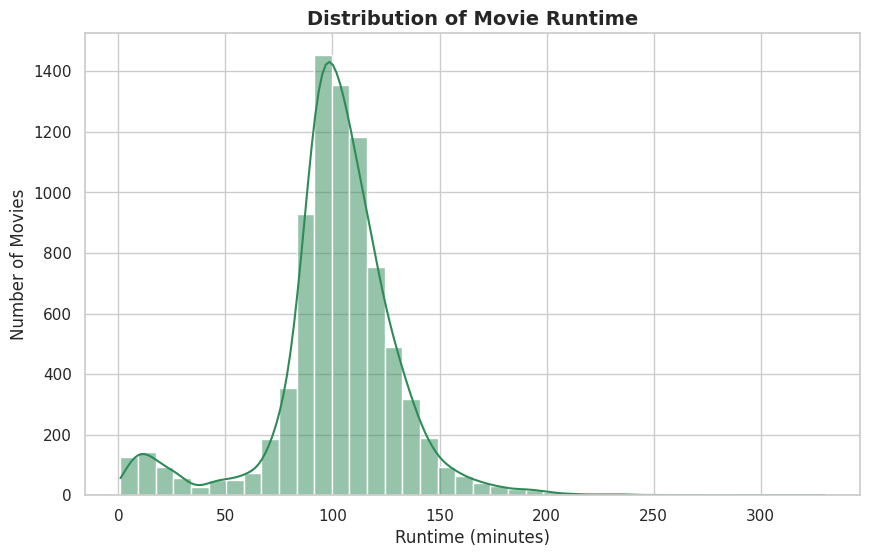

In [ ]:
runtime_clean = organized_df[(organized_df['runtime'] > 0) & (organized_df['runtime'] < 400)]
sns.histplot(runtime_clean['runtime'], bins=40, kde=True, color='seagreen')
plt.title('Distribution of Movie Runtime')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.show()

*Distribution of budget and revenue (log scale, movies with both > 0 only — raw scale is unreadable due to the huge right skew)*

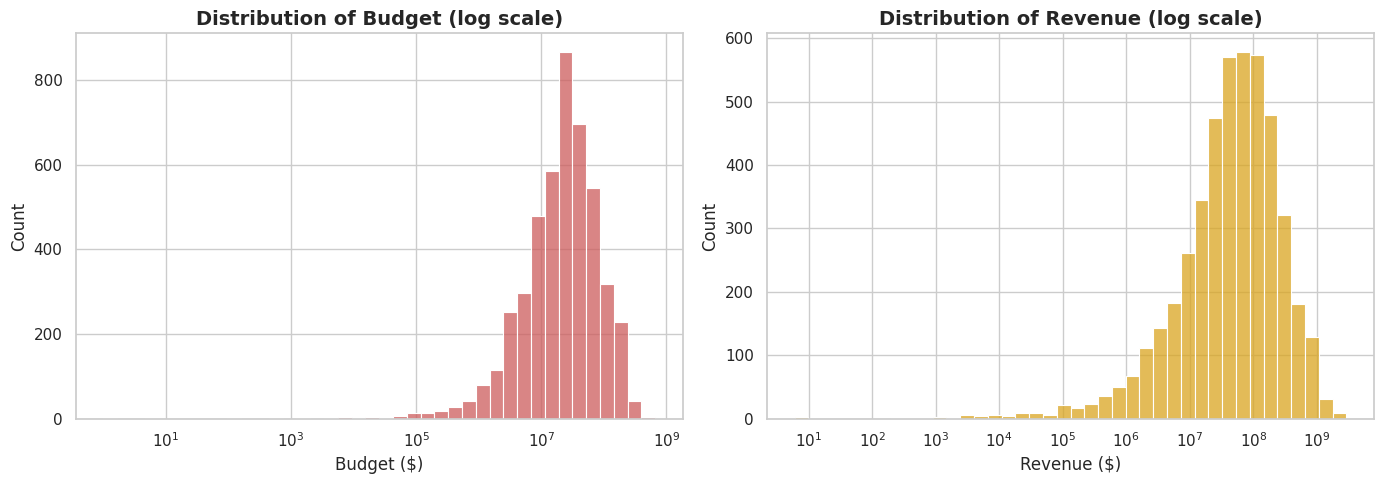

In [ ]:
financial_nonzero = organized_df[(organized_df['budget'] > 0) & (organized_df['revenue'] > 0)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(financial_nonzero['budget'], bins=40, log_scale=True, ax=axes[0], color='indianred')
axes[0].set_title('Distribution of Budget (log scale)')
axes[0].set_xlabel('Budget ($)')
sns.histplot(financial_nonzero['revenue'], bins=40, log_scale=True, ax=axes[1], color='goldenrod')
axes[1].set_title('Distribution of Revenue (log scale)')
axes[1].set_xlabel('Revenue ($)')
plt.tight_layout()
plt.show()

*Rating spread by genre — box plot to spot outliers and consistency within each genre (top 10 genres by volume)*

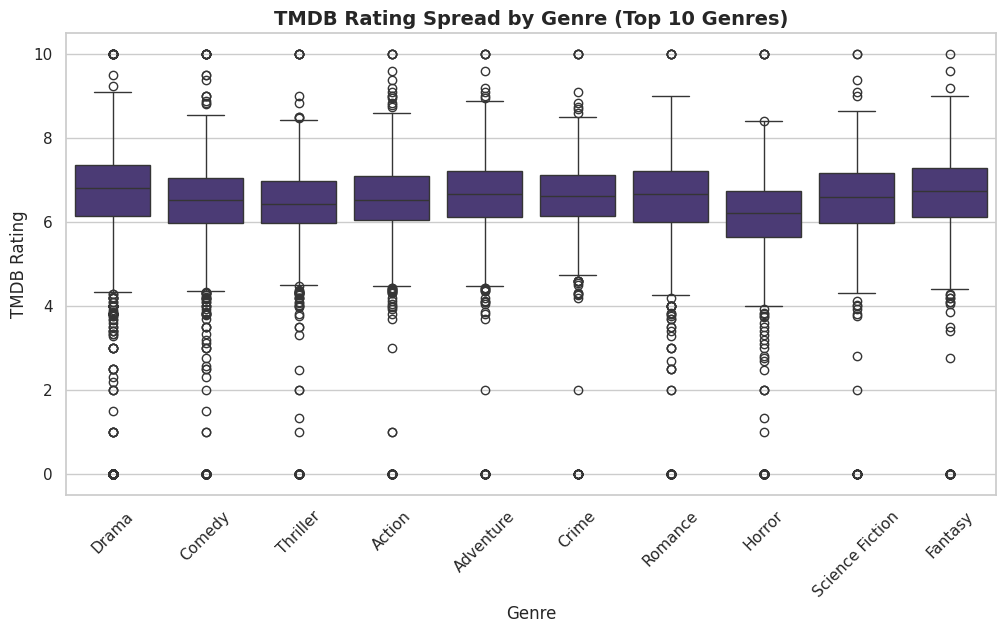

In [ ]:
top_genres = organized_df.explode('genre')['genre'].value_counts().head(10).index.tolist()
genre_exploded = organized_df.explode('genre')
genre_exploded_top = genre_exploded[genre_exploded['genre'].isin(top_genres)]
plt.figure(figsize=(12, 6))
sns.boxplot(data=genre_exploded_top, x='genre', y='TMDB_rating', order=top_genres)
plt.xticks(rotation=45)
plt.title('TMDB Rating Spread by Genre (Top 10 Genres)')
plt.xlabel('Genre')
plt.ylabel('TMDB Rating')
plt.show()

*Profit spread by genre — same idea, but for financial performance (complete financial data only, extreme outliers hidden so the boxes stay readable)*

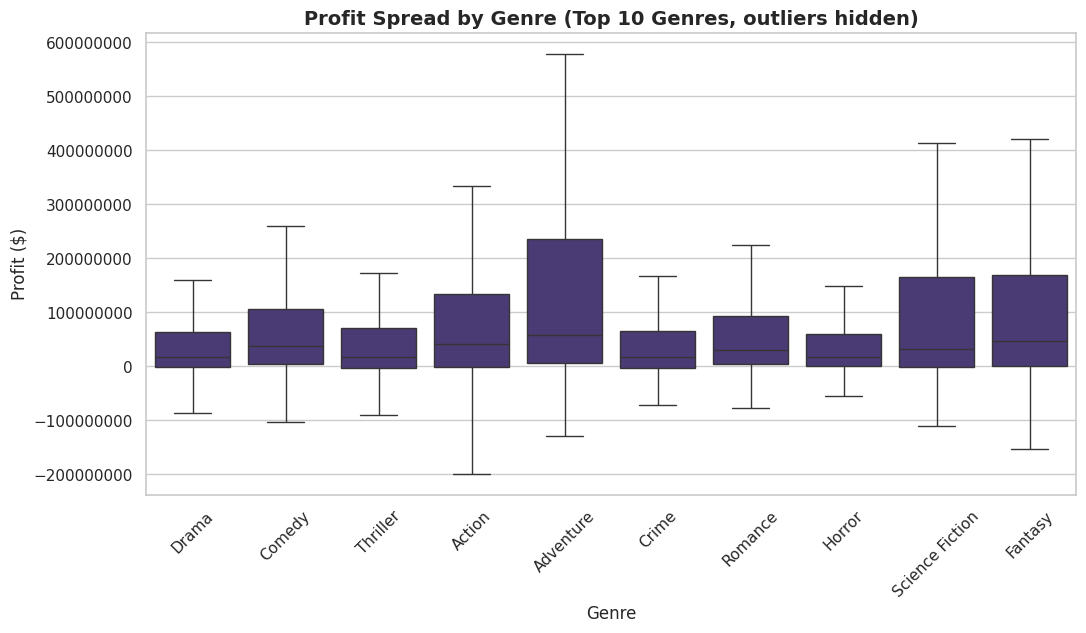

In [ ]:
genre_exploded_complete = genre_exploded_top[genre_exploded_top['financial_status'] == 'Complete']
plt.figure(figsize=(12, 6))
sns.boxplot(data=genre_exploded_complete, x='genre', y='calculated_profit', order=top_genres, showfliers=False)
plt.xticks(rotation=45)
plt.title('Profit Spread by Genre (Top 10 Genres, outliers hidden)')
plt.xlabel('Genre')
plt.ylabel('Profit ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

*Correlation heatmap across all key numeric features (consolidates the pairwise `.corr()` calls above into one view)*

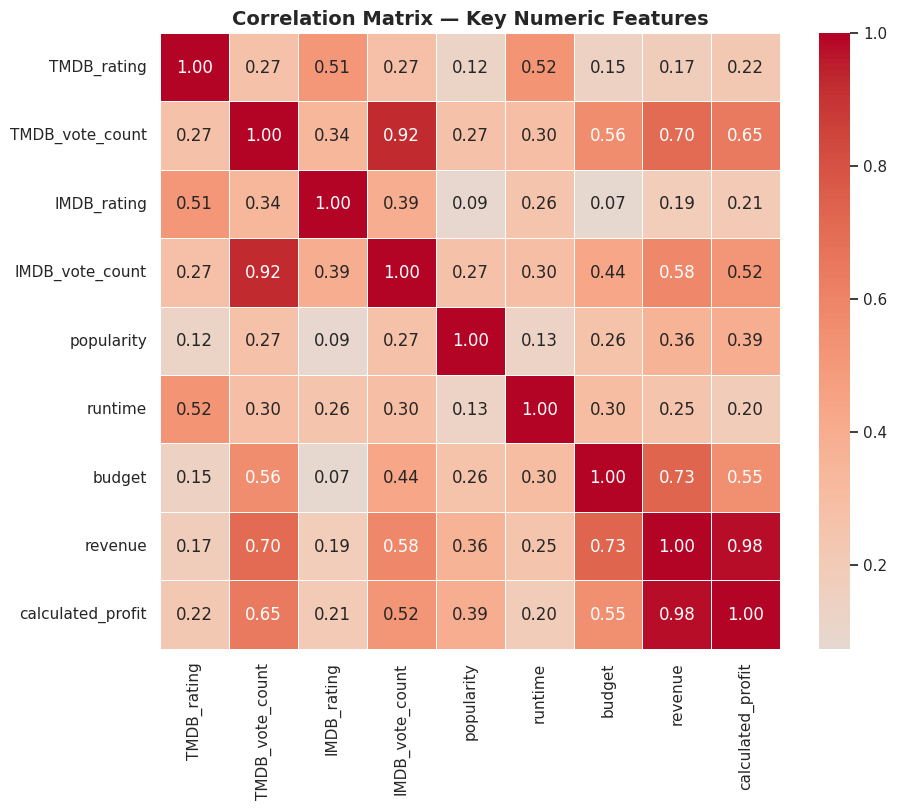

In [ ]:
numeric_cols = ['TMDB_rating', 'TMDB_vote_count', 'IMDB_rating', 'IMDB_vote_count','popularity', 'runtime', 'budget', 'revenue', 'calculated_profit']
corr_matrix = organized_df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix — Key Numeric Features')
plt.show()

*How much of the dataset has complete financial data?*

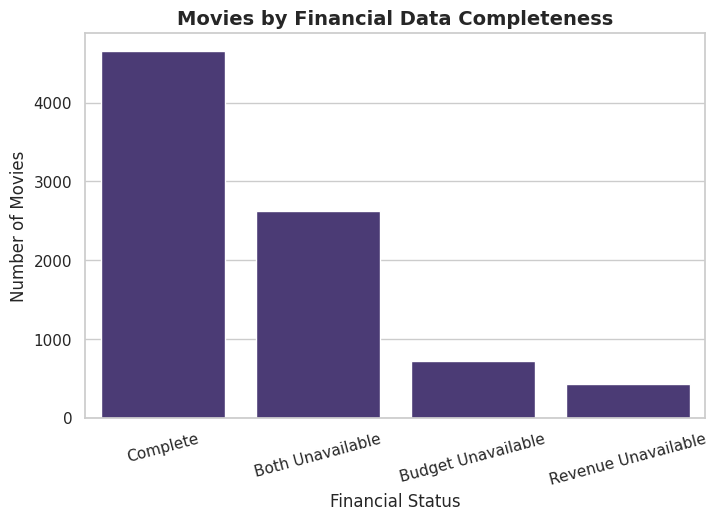

In [ ]:
financial_status_counts = organized_df['financial_status'].value_counts().reset_index()
financial_status_counts.columns = ['financial_status', 'count']
plt.figure(figsize=(8, 5))
sns.barplot(
    data=financial_status_counts,
    x='financial_status',    y='count',
    order=financial_status_counts.sort_values('count', ascending=False)['financial_status'])
plt.title('Movies by Financial Data Completeness')
plt.xlabel('Financial Status')
plt.ylabel('Number of Movies')
plt.xticks(rotation=15)
plt.show()

*Top 15 genres by movie count — bar chart version of the value_counts table earlier*

/tmp/ipykernel_3274/2092400643.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_counts, x='count', y='genre', palette='viridis')


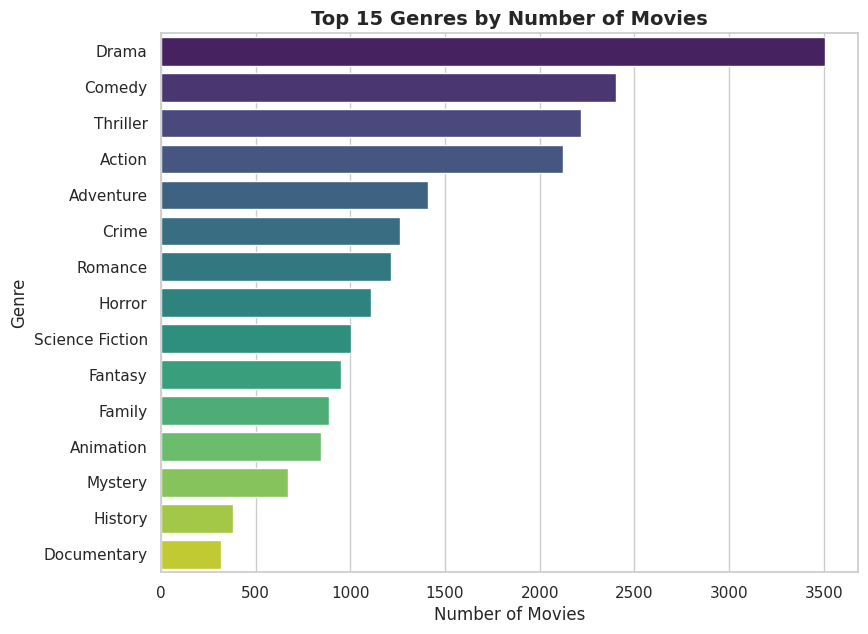

In [ ]:
genre_counts = organized_df.explode('genre')['genre'].value_counts().head(15).reset_index()
genre_counts.columns = ['genre', 'count']
plt.figure(figsize=(9, 7))
sns.barplot(data=genre_counts, x='count', y='genre', palette='viridis')
plt.title('Top 15 Genres by Number of Movies')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()

## EXPORT FOR POWER BI — STAR SCHEMA`genre`, `production_companies`, and `production_countries` are list-type columns — they won't work correctly in Power BI as-is. We split `organized_df` into one **fact table** (one row per movie, scalar columns only) plus three **bridge tables** (one row per movie–value pair), related on `id`.

*1. Fact table — one row per movie, no list-type columns*

In [ ]:
fact_columns = [
    'id', 'title', 'adult', 'original_language', 'runtime', 'popularity',
    'release_date', 'release_year', 'TMDB_rating', 'TMDB_vote_count',
    'IMDB_rating', 'IMDB_vote_count', 'revenue', 'budget', 'profit',
    'calculated_profit', 'financial_status'
    ]
movies_fact = organized_df[fact_columns].copy()
print("movies_fact shape:", movies_fact.shape)
movies_fact.head()

movies_fact shape: (8418, 17)


,id,title,adult,original_language,runtime,popularity,release_date,release_year,TMDB_rating,TMDB_vote_count,IMDB_rating,IMDB_vote_count,revenue,budget,profit,calculated_profit,financial_status
0,969681,Spider-Man: Brand New Day,False,English,145,857.7444,2026-07-29,2026,7.878,2402,8.0,309807.0,2335246398,225000000,2110246398,2.110246e+09,Complete
1,1368337,The Odyssey,False,English,173,497.9764,2026-07-15,2026,7.997,3440,8.4,507933.0,1555182696,250000000,1305182696,1.305183e+09,Complete
2,1288445,Mutiny,False,English,95,392.0104,2026-08-19,2026,6.371,264,5.7,21710.0,20824283,40000000,-19175717,-1.917572e+07,Complete
3,1204680,Coyote vs. Acme,False,English,103,324.8273,2026-08-20,2026,7.800,118,7.5,31279.0,17468850,72000000,-54531150,-5.453115e+07,Complete
4,1285366,Shape of My Heart,False,Japanese,91,309.2067,2024-07-06,2024,5.200,5,6.3,33.0,0,0,0,NaN,Both Unavailable


*2. Genre bridge table*

In [ ]:
movie_genre_bridge = (
    organized_df[['id', 'genre']]
    .explode('genre')
    .dropna(subset=['genre'])
    .reset_index(drop=True))
print("movie_genre_bridge shape:", movie_genre_bridge.shape)
movie_genre_bridge.head()

movie_genre_bridge shape: (21169, 2)


,id,genre
0,969681,Science Fiction
1,969681,Action
2,969681,Adventure
3,1368337,Adventure
4,1368337,Action


*3. Production company bridge table (drops 'Unknown' placeholders)*

In [ ]:
movie_company_bridge = (
    organized_df[['id', 'production_companies']]
    .explode('production_companies')
    .rename(columns={'production_companies': 'production_company'})
    .dropna(subset=['production_company']))
movie_company_bridge = movie_company_bridge[movie_company_bridge['production_company'] != 'Unknown'].reset_index(drop=True)
print("movie_company_bridge shape:", movie_company_bridge.shape)
movie_company_bridge.head()

movie_company_bridge shape: (25597, 2)


,id,production_company
0,969681,Marvel Studios
1,969681,Columbia Pictures
2,969681,Pascal Pictures
3,969681,TSG Entertainment
4,1368337,Universal Pictures


*4. Production country bridge table (drops 'Unknown' placeholders)*

In [ ]:
movie_country_bridge = (
    organized_df[['id', 'production_countries']]
    .explode('production_countries')
    .rename(columns={'production_countries': 'production_country'})
    .dropna(subset=['production_country']))
movie_country_bridge = movie_country_bridge[movie_country_bridge['production_country'] != 'Unknown'].reset_index(drop=True)
print("movie_country_bridge shape:", movie_country_bridge.shape)
movie_country_bridge.head()

movie_country_bridge shape: (11768, 2)


,id,production_country
0,969681,United States of America
1,1368337,United Kingdom
2,1368337,United States of America
3,1288445,United Kingdom
4,1288445,United States of America


*5. Save all four tables to CSV, ready to import into Power BI*

In [ ]:
movies_fact.to_csv('movies_fact.csv', index=False)
movie_genre_bridge.to_csv('movie_genre_bridge.csv', index=False)
movie_company_bridge.to_csv('movie_company_bridge.csv', index=False)
movie_country_bridge.to_csv('movie_country_bridge.csv', index=False)
print("Exported: movies_fact.csv, movie_genre_bridge.csv, movie_company_bridge.csv, movie_country_bridge.csv")

Exported: movies_fact.csv, movie_genre_bridge.csv, movie_company_bridge.csv, movie_country_bridge.csv
